# AOG-HKG Stage 1/Stage 2 Diagnostic Notebook

This notebook visualizes and audits the intermediate outputs of the two-stage part-compositional pipeline.

It is designed for the AOG-inspired Stage 2 implementation:

- **Stage 1:** functional part masks, role masks, support mask, presence scores, and part/role tokens.
- **Stage 2:** AOG-HKG template selection, activated parse graph, node/edge/motif contributions, calibrated fusion, and branch-level classification behavior.

The notebook also computes statistical diagnostics:

- Stage-1 per-part IoU, Dice, presence F1, hallucination rate, and miss rate.
- Stage-2 final/base/HKG/node/edge/motif accuracy, macro accuracy, ECE, true-class rank, rescue/damage rates.
- Per-class performance, confusion matrix, calibration curve, template usage, and relation residual statistics.

Run this notebook from the project root or from the `notebooks/` directory. Edit the checkpoint and dataset paths in the next cell before running.

In [1]:
from pathlib import Path
import sys
import os
import math
import json
import re
import zipfile
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

# Resolve project root whether this notebook is opened from ./notebooks or project root.
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" and (CWD.parent / "src").exists() else CWD
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from partcat_hkg.analysis.aog_diagnostics import (
    load_aog_hkg_diagnostic_context,
    summarize_aog_hkg,
    compute_stage1_statistics,
    collect_stage2_predictions,
    summarize_classification,
    plot_stage1_sample,
    plot_stage1_part_detail,
    make_balanced_diagnostic_loader,
    summarize_diagnostic_loader,
    plot_aog_parse_sample,
    plot_hkg_template_configuration,
    plot_hkg_class_templates_grid,
    plot_parse_configuration_and_motifs,
    summarize_template_structure_quality,
    plot_confusion_matrix,
    plot_calibration_curve,
    collect_edge_residuals,
    save_diagnostic_tables,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)
torch.set_grad_enabled(False)
print("PROJECT_ROOT =", PROJECT_ROOT)

# ---------------------------------------------------------------------------
# Figure export helpers
# ---------------------------------------------------------------------------
# These helpers save every diagnostic figure as a standalone image file while
# still displaying it in the notebook. FIGURE_DIR is configured in the next
# setup cell and defaults to a subfolder next to this notebook.
_saved_figures = []
_fig_counter = 0

def _safe_fig_name(name: str) -> str:
    name = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name)).strip("_")
    return name or "figure"

def save_figure(fig, name: str, *, subdir: str | None = None, dpi: int | None = None):
    """Save a matplotlib figure to FIGURE_DIR and record it in a manifest.

    The notebook keeps displaying figures normally; this function only adds a
    local PNG export. Enable/disable through SAVE_FIGURES in the config cell.
    """
    global _fig_counter
    if not globals().get("SAVE_FIGURES", False):
        return None
    base_dir = Path(globals().get("FIGURE_DIR", Path.cwd() / "aog_hkg_diagnostic_images"))
    out_dir = base_dir / _safe_fig_name(subdir) if subdir else base_dir
    out_dir.mkdir(parents=True, exist_ok=True)
    _fig_counter += 1
    dpi = int(dpi or globals().get("FIGURE_DPI", 180))
    filename = f"{_fig_counter:03d}_{_safe_fig_name(name)}.png"
    path = out_dir / filename
    fig.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    record = {
        "idx": _fig_counter,
        "name": str(name),
        "path": str(path),
        "filename": path.name,
        "subdir": str(subdir or ""),
    }
    if globals().get("SAVE_PDF_FIGURES", False):
        pdf_path = path.with_suffix(".pdf")
        fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
        record["pdf_path"] = str(pdf_path)
    _saved_figures.append(record)
    print(f"[saved figure] {path}")
    return path

def finalize_figure_exports():
    """Write a manifest and zip file for all saved figures."""
    base_dir = Path(globals().get("FIGURE_DIR", Path.cwd() / "aog_hkg_diagnostic_images"))
    base_dir.mkdir(parents=True, exist_ok=True)
    manifest = pd.DataFrame(_saved_figures)
    manifest_csv = base_dir / "figure_manifest.csv"
    manifest_json = base_dir / "figure_manifest.json"
    manifest.to_csv(manifest_csv, index=False)
    manifest.to_json(manifest_json, orient="records", indent=2)

    zip_path = base_dir.parent / f"{base_dir.name}.zip"
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for file_path in sorted(base_dir.rglob("*")):
            if file_path.is_file():
                zf.write(file_path, arcname=file_path.relative_to(base_dir.parent))
    print(f"Saved {len(manifest)} figures to {base_dir}")
    print(f"Zipped figures to {zip_path}")
    return manifest, zip_path


PROJECT_ROOT = /home/dfli/partcat_hkg_v3


## 1. Configure paths and diagnostic budget

Use a small `MAX_BATCHES` first to confirm the setup, then increase it for real statistics. The Stage-2 checkpoint is optional but recommended; without it, the notebook visualizes an untrained Stage-2 head on top of the loaded Stage-1/HKG.

In [2]:
# --- Required paths ---------------------------------------------------------
CONFIG_PATH = PROJECT_ROOT / "configs" / "stage1_quality_upgrade.yaml"
PARTIMAGENET_ROOT = "../../full_hyco/PartImageNet"  # edit this
STAGE1_CKPT = PROJECT_ROOT / "runs" / "stage1_quality_upgrade" / "checkpoints" / "stage1_best.pt"
HKG_PATH = PROJECT_ROOT / "runs" / "stage1_quality_upgrade" / "checkpoints" / "aog_hkg.pt"
STAGE2_CKPT = PROJECT_ROOT / "runs" / "stage2_aog_hkg" / "checkpoints" / "stage2_aog_hkg_best.pt"

# --- Runtime / diagnostics --------------------------------------------------
DEVICE = "auto"          # "auto", "cuda", "cuda:0", or "cpu"
NUM_WORKERS = 0          # use 0 inside notebooks unless you know multiprocessing is safe
BATCH_SIZE = 4
MAX_VAL_SAMPLES = 0      # 0 means use config/default; set e.g. 128 for fast debugging
MAX_BATCHES = None       # None = use the balanced diagnostic loader completely; avoid first-class-only slices
VIS_SAMPLES = 3
USE_BALANCED_DIAGNOSTIC_LOADER = True
DIAGNOSTIC_SAMPLES_PER_CLASS = 8
DIAGNOSTIC_SEED = 0
MASK_THRESHOLD = 0.40
PRESENCE_THRESHOLD = 0.15
OUTPUT_DIR = PROJECT_ROOT / "runs" / "diagnostics" / "aog_hkg"



# --- Figure export ----------------------------------------------------------
# Images are saved to a folder beside this notebook. This keeps uploads simple:
# zip or upload files from notebooks/aog_hkg_diagnostic_images/.
SAVE_FIGURES = True
FIGURE_DPI = 180
SAVE_PDF_FIGURES = False
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" if (PROJECT_ROOT / "notebooks").exists() else Path.cwd()
FIGURE_DIR = NOTEBOOK_DIR / "aog_hkg_diagnostic_images"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print("Figure output directory:", FIGURE_DIR)

# Make optional checkpoint handling convenient.
STAGE2_CKPT = STAGE2_CKPT if Path(STAGE2_CKPT).exists() else None
print("Stage 2 checkpoint:", STAGE2_CKPT)

Figure output directory: /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images
Stage 2 checkpoint: /home/dfli/partcat_hkg_v3/runs/stage2_aog_hkg/checkpoints/stage2_aog_hkg_best.pt


## 2. Load dataset, Stage 1, AOG-HKG, and Stage 2

In [3]:
ctx = load_aog_hkg_diagnostic_context(
    CONFIG_PATH,
    stage1_ckpt=STAGE1_CKPT,
    hkg_path=HKG_PATH,
    stage2_ckpt=STAGE2_CKPT,
    partimagenet_root=PARTIMAGENET_ROOT,
    device=DEVICE,
    num_workers=NUM_WORKERS,
    batch_size=BATCH_SIZE,
    max_val_samples=(MAX_VAL_SAMPLES or None),
)

cfg = ctx["cfg"]
device = ctx["device"]
schema = ctx["schema"]
kg = ctx["kg"]
stage1 = ctx["stage1"]
model = ctx["model"]
val_loader = ctx["stage1_val"]

print("device:", device)
print("schema:", f"C={schema.num_classes}, F={schema.num_parts}, R={schema.num_roles}")
print("HKG:", f"templates/class={kg.num_templates}, edges={kg.template_edges.shape[0]}, motifs={kg.motif_edges.shape[0]}")

# Use a class-balanced diagnostic loader by default.  The raw validation loader is
# usually class-ordered; with a small MAX_BATCHES it can silently evaluate only
# the first class and produce misleading confusion/calibration/template plots.
if USE_BALANCED_DIAGNOSTIC_LOADER:
    diag_loader = make_balanced_diagnostic_loader(
        ctx["val_ds"],
        batch_size=BATCH_SIZE,
        samples_per_class=DIAGNOSTIC_SAMPLES_PER_CLASS,
        seed=DIAGNOSTIC_SEED,
        num_workers=NUM_WORKERS,
    )
else:
    diag_loader = val_loader

print("Diagnostic loader class balance:")
diag_balance = summarize_diagnostic_loader(diag_loader)
display(diag_balance)
if len(diag_balance) <= 1:
    print("WARNING: diagnostic loader contains <=1 class. Metrics below are not global validation metrics.")


[dataset] train.json: 20457 samples | C=11 F=13 R=40
[dataset] val.json: 1205 samples | C=11 F=13 R=40
[datasets] train: ../../full_hyco/PartImageNet/annotations/train/train.json | images: ../../full_hyco/PartImageNet/images/train | samples: 20457
[datasets] val: ../../full_hyco/PartImageNet/annotations/val/val.json | images: ../../full_hyco/PartImageNet/images/val | samples: 1205


/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/dfli/anaconda3/envs/partviz/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened becau

device: cuda
schema: C=11, F=13, R=40
HKG: templates/class=3, edges=97, motifs=63
Diagnostic loader class balance:


,class_idx,class,count
0,0,aeroplane,8
1,1,bicycle,8
2,2,biped,8
3,3,bird,8
4,4,boat,8
5,5,bottle,8
6,6,car,8
7,7,fish,8
8,8,quadruped,8
9,9,reptile,8


## 3. Inspect the learned AOG-HKG structure

This audits the class-level grammar before looking at any individual image. Check whether classes have valid templates, whether template priors are degenerate, whether required roles make sense, and whether edge/motif counts are reasonable.

In [4]:
hkg_tables = summarize_aog_hkg(kg)
print("Templates")
display(hkg_tables["templates"].head(20))
print("Edges")
display(hkg_tables["edges"].head(20))
print("Motifs")
display(hkg_tables["motifs"].head(20))

Templates


,class_idx,class,template,valid,prior,required_count,mean_role_prior,edge_count,motif_count,top_roles
0,0,aeroplane,0,True,0.797753,5,0.371446,7,4,"head:1.00, tail:1.00, body:1.00, wing:0.96, engine:0.88"
1,0,aeroplane,1,True,0.146067,4,0.259436,6,6,"head:1.00, body:0.92, wing:0.69, engine:0.66, tail:0.10"
2,0,aeroplane,2,True,0.056180,4,0.238635,4,2,"body:0.93, wing:0.79, tail:0.79, engine:0.52, head:0.06"
3,1,bicycle,0,True,0.756906,4,0.279501,5,4,"wheel:1.00, head:1.00, body:1.00, seat:0.64, sail:0.00"
4,1,bicycle,1,True,0.224678,3,0.195698,3,2,"wheel:1.00, body:0.82, seat:0.72, head:0.01, mirror:0.00"
5,1,bicycle,2,True,0.018416,3,0.179818,3,2,"body:1.00, seat:0.67, head:0.58, wheel:0.10, mirror:0.00"
6,2,biped,0,True,0.606244,4,0.336528,7,5,"foot:1.00, head:1.00, hand:0.98, body:0.98, tail:0.42"
7,2,biped,1,True,0.339702,3,0.191379,3,1,"head:1.00, body:0.90, hand:0.59, foot:0.00, tail:0.00"
8,2,biped,2,True,0.054054,4,0.287601,5,4,"tail:0.99, body:0.98, head:0.97, hand:0.78, foot:0.01"
9,3,bird,0,True,0.505020,4,0.304614,6,4,"head:1.00, foot:1.00, body:1.00, tail:0.96, wing:0.00"


Edges


,edge_idx,class_idx,class,template,part_i_idx,part_i,part_j_idx,part_j,relation_type,support,information_gain,top_template_channel,top_template_channel_strength,mu_dx,var_dx,mu_dy,var_dy,mu_dist,var_dist,mu_area_i,var_area_i,mu_area_j,var_area_j,mu_log_area_ratio,var_log_area_ratio,mu_bbox_w_i,var_bbox_w_i,mu_bbox_h_i,var_bbox_h_i,mu_bbox_w_j,var_bbox_w_j,mu_bbox_h_j,var_bbox_h_j,mu_iou,var_iou,mu_contact,var_contact,mu_contain_i_in_j,var_contain_i_in_j,mu_contain_j_in_i,var_contain_j_in_i
2,2,0,aeroplane,0,5,head,10,tail,axis/extremity,1.000000,0.219076,above,0.142106,-0.039056,0.579369,-0.142106,0.162954,0.867248,0.018442,0.087263,0.008437,0.078197,0.002523,-0.365473,10.468977,0.264077,0.039615,0.471086,0.057831,0.258366,0.032696,0.663178,0.064563,0.001069,0.001000,0.005801,0.005313,0.004316,0.003469,0.001589,0.001345
0,0,0,aeroplane,0,0,body,10,tail,lateral-or-appendage,0.995283,0.298491,above,0.270478,-0.024166,0.215645,-0.270478,0.048188,0.576620,0.011000,0.321794,0.008484,0.068624,0.001343,1.887872,2.859166,0.871931,0.014426,0.703104,0.045847,0.269181,0.029699,0.554741,0.043748,0.002418,0.001017,0.020790,0.002857,0.003089,0.001099,0.013611,0.002346
1,1,0,aeroplane,0,0,body,5,head,attached-to-body,0.995283,0.262449,touching,0.280181,0.011746,0.150717,-0.150520,0.055097,0.466916,0.010630,0.452704,0.017272,0.100780,0.006467,2.262389,7.346331,0.879937,0.007097,0.937115,0.013764,0.277130,0.032498,0.531649,0.052190,0.045243,0.002791,0.280181,0.050973,0.056560,0.005141,0.235222,0.041338
4,4,0,aeroplane,0,5,head,12,wing,anchor-bond,0.957547,0.076874,below,0.153477,-0.018409,0.223367,0.153477,0.070563,0.540316,0.025773,0.066870,0.003476,0.176823,0.007888,-1.768460,8.137316,0.192077,0.015098,0.495655,0.092361,0.805698,0.037150,0.817049,0.040859,0.004329,0.001000,0.023666,0.009893,0.017867,0.006636,0.005505,0.001215
5,5,0,aeroplane,0,10,tail,12,wing,generic-spatial,0.957547,0.144652,below,0.293931,0.032846,0.108850,0.293931,0.053685,0.478678,0.025684,0.069425,0.002940,0.182024,0.008398,-1.385287,3.860037,0.260507,0.032036,0.538801,0.047322,0.960713,0.011853,0.716676,0.072253,0.023595,0.001914,0.164689,0.071946,0.127104,0.050652,0.032188,0.004869
3,3,0,aeroplane,0,0,body,12,wing,lateral-or-appendage,0.952830,0.107730,near,0.394746,-0.002435,0.047754,0.015382,0.021679,0.232378,0.015881,0.297779,0.029395,0.179567,0.009654,0.465913,1.019943,0.701635,0.052936,0.780364,0.064058,0.847776,0.031384,0.776866,0.045376,0.100068,0.007929,0.370335,0.066339,0.169256,0.024225,0.277487,0.053134
6,6,0,aeroplane,0,0,body,1,engine,attached-to-body,0.872642,0.002464,near,0.240697,-0.001583,0.087710,0.086074,0.059098,0.356055,0.027444,0.435904,0.020716,0.100876,0.005796,1.806168,2.795207,0.883292,0.029280,0.905222,0.022747,0.479588,0.100687,0.519575,0.050313,0.030804,0.001764,0.213626,0.052772,0.042998,0.007334,0.162622,0.038321
7,7,0,aeroplane,1,0,body,5,head,attached-to-body,0.921053,0.187838,touching,0.347321,-0.020904,0.124140,-0.139083,0.056715,0.440412,0.007270,0.477253,0.020824,0.141136,0.011941,1.515791,1.302389,0.897958,0.011711,0.924993,0.014377,0.391867,0.033901,0.532743,0.047031,0.056347,0.002130,0.347321,0.065720,0.075623,0.005889,0.294235,0.053836
8,8,0,aeroplane,1,5,head,12,wing,anchor-bond,0.684211,0.063201,below,0.194224,0.052585,0.159888,0.194224,0.105924,0.514034,0.045311,0.081083,0.006340,0.180307,0.010231,-0.908327,8.818203,0.270526,0.028551,0.465899,0.110197,0.809198,0.079265,0.718512,0.079197,0.001817,0.001000,0.026205,0.013590,0.018729,0.009589,0.002534,0.001006
11,11,0,aeroplane,1,1,engine,5,head,anchor-bond,0.657895,0.017688,above,0.237542,0.020528,0.240783,-0.237542,0.124831,0.613366,0.044429,0.142604,0.012043,0.135672,0.007106,-0.155935,7.689956,0.685527,0.105970,0.628203,0.071770,0.338801,0.037087,0.590042,0.072098,0.012106,0.002262,0.045435,0.022060,0.018243,0.004981,0.037227,0.015919


Motifs


,motif_idx,class_idx,class,template,part_i,part_j,motif_type,support
0,0,0,aeroplane,0,body,tail,appendage,0.995283
1,1,0,aeroplane,0,body,head,containment,0.995283
2,2,0,aeroplane,0,body,wing,containment,0.952830
3,3,0,aeroplane,0,body,engine,appendage,0.872642
4,4,0,aeroplane,1,body,head,containment,0.921053
5,5,0,aeroplane,1,head,wing,appendage,0.684211
6,6,0,aeroplane,1,body,wing,containment,0.605263
7,7,0,aeroplane,1,body,engine,containment,0.605263
8,8,0,aeroplane,1,engine,head,appendage,0.657895
9,9,0,aeroplane,1,engine,wing,containment,0.578947


[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/001_hkg_structure_histograms.png


PosixPath('/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/001_hkg_structure_histograms.png')

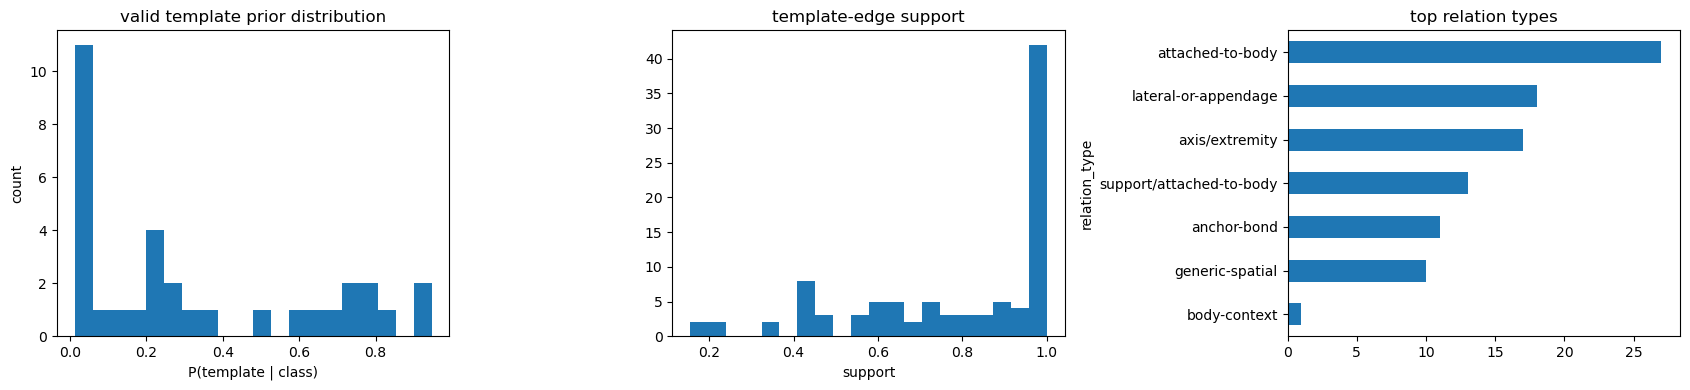

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

valid_templates = hkg_tables["templates"][hkg_tables["templates"]["valid"]]
axes[0].hist(valid_templates["prior"].to_numpy(), bins=20)
axes[0].set_title("valid template prior distribution")
axes[0].set_xlabel("P(template | class)")
axes[0].set_ylabel("count")

if len(hkg_tables["edges"]):
    axes[1].hist(hkg_tables["edges"]["support"].to_numpy(), bins=20)
    axes[1].set_title("template-edge support")
    axes[1].set_xlabel("support")
else:
    axes[1].set_title("no template edges")

if len(hkg_tables["edges"]):
    hkg_tables["edges"]["relation_type"].value_counts().head(12).iloc[::-1].plot.barh(ax=axes[2])
    axes[2].set_title("top relation types")
else:
    axes[2].set_title("no relation types")

fig.tight_layout()
save_figure(fig, "hkg_structure_histograms")

## 3b. Direct class-template configuration views

The previous tables tell you how many roles, edges, and motifs exist, but they do not show the configuration directly.

These plots draw the HKG grammar branch itself:

- circle/square nodes are functional part roles; square means the role is required by the selected template,
- node size is the learned template role prior,
- solid lines are learned template relation edges,
- dashed lines are motif factors,
- the layout is qualitative: relation means are normalized in each pair's union-box frame, so the graph shows relative direction/grouping rather than exact metric geometry.


Template structure quality, densest templates first


,class_idx,class,template,prior,active_roles@0.05,required_roles,edge_count,motif_count,mean_edge_support,mean_edge_ig,motif_to_edge_ratio,top_roles
11,3,bird,2,0.238956,5,5,8,7,0.843158,0.217654,0.875000,"wing:1.00, head:0.99, body:0.97, tail:0.91, foot:0.74"
6,2,biped,0,0.606244,5,4,7,5,0.818132,0.076156,0.714286,"foot:1.00, head:1.00, hand:0.98, body:0.98, tail:0.42"
0,0,aeroplane,0,0.797753,5,5,7,4,0.961590,0.158819,0.571429,"head:1.00, tail:1.00, body:1.00, wing:0.96, engine:0.88"
1,0,aeroplane,1,0.146067,5,4,6,6,0.675439,0.064549,1.000000,"head:1.00, body:0.92, wing:0.69, engine:0.66, tail:0.10"
24,8,quadruped,0,0.764396,4,4,6,5,0.717187,0.029458,0.833333,"foot:1.00, head:1.00, body:0.98, tail:0.45, seat:0.00"
9,3,bird,0,0.505020,4,4,6,4,0.980099,0.295056,0.666667,"head:1.00, foot:1.00, body:1.00, tail:0.96, wing:0.00"
27,9,reptile,0,0.906351,4,4,6,2,0.730985,0.046109,0.333333,"foot:1.00, body:0.99, head:0.99, tail:0.48, mirror:0.00"
3,1,bicycle,0,0.756906,4,4,5,4,0.853659,0.189183,0.800000,"wheel:1.00, head:1.00, body:1.00, seat:0.64, sail:0.00"
8,2,biped,2,0.054054,4,4,5,4,0.899130,0.042823,0.800000,"tail:0.99, body:0.98, head:0.97, hand:0.78, foot:0.01"
10,3,bird,1,0.256024,5,2,5,2,0.387426,0.048033,0.400000,"head:1.00, body:0.90, tail:0.37, foot:0.16, wing:0.07"


[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/002_hkg_class_templates_grid_car.png


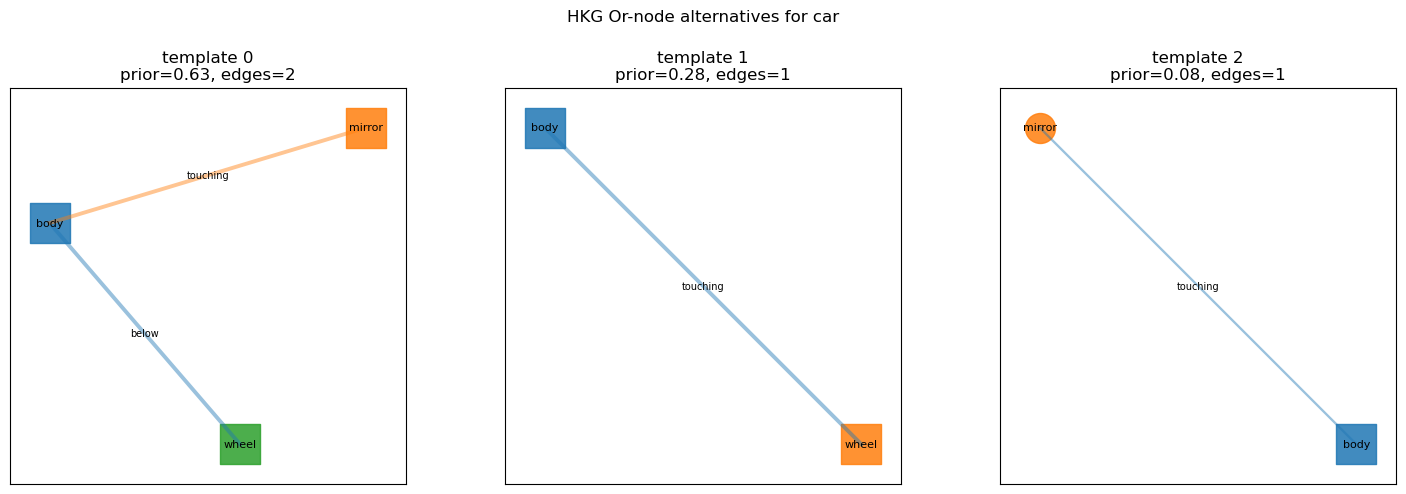

[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/003_hkg_template_configuration_car.png


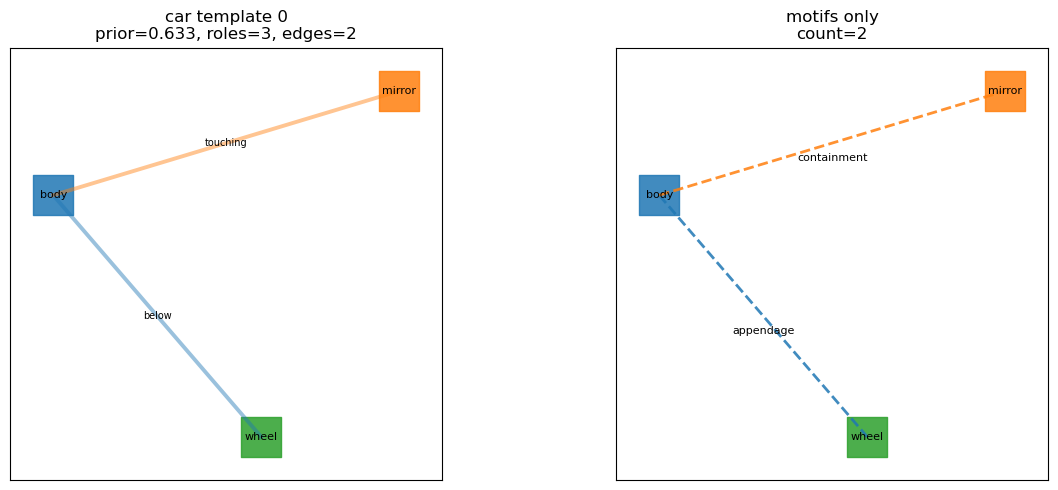

Top roles for car


,part_idx,part,role_prior,required
2,11,wheel,0.999930,True
1,6,mirror,0.999722,True
0,0,body,0.999159,True


Template edges for car


,edge_idx,part_i_idx,part_i,part_j_idx,part_j,support,information_gain,relation_type,top_template_channel,top_template_channel_strength,dx,dy,dist
0,64,0,body,11,wheel,0.99916,0.104555,support/attached-to-body,below,0.323162,0.007033,0.323162,0.365265
1,65,0,body,6,mirror,0.99916,0.000492,attached-to-body,touching,0.779891,0.011697,-0.139455,0.287449


Motifs for car


,motif_idx,part_i_idx,part_i,part_j_idx,part_j,motif_type,support
0,43,0,body,11,wheel,appendage,0.99916
1,44,0,body,6,mirror,containment,0.99916


[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/004_hkg_class_templates_grid_aeroplane.png


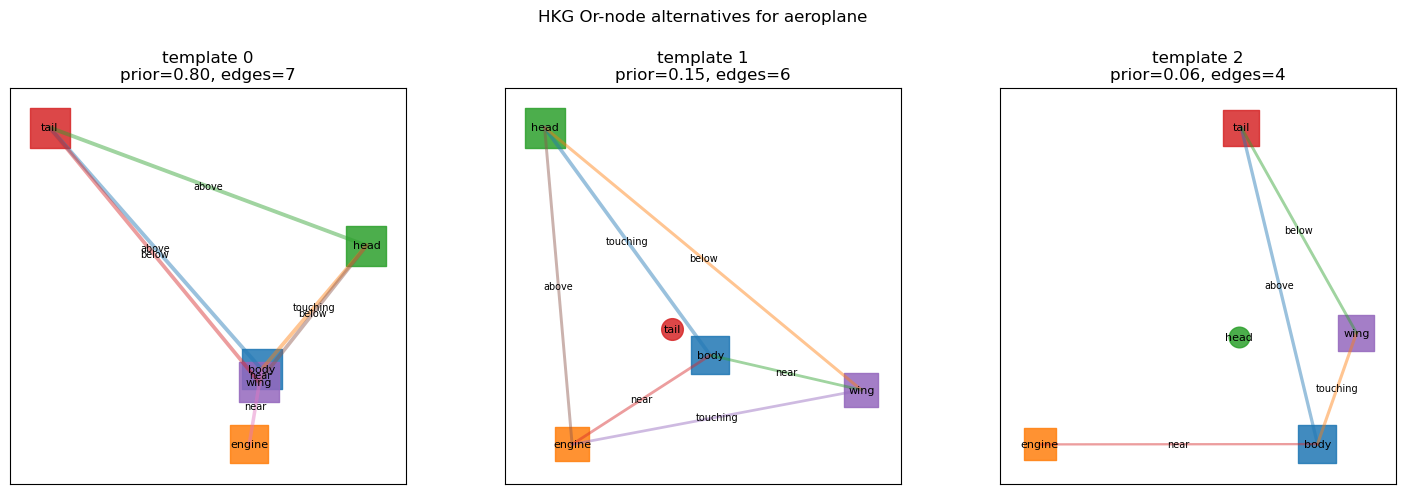

[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/005_hkg_template_configuration_aeroplane.png


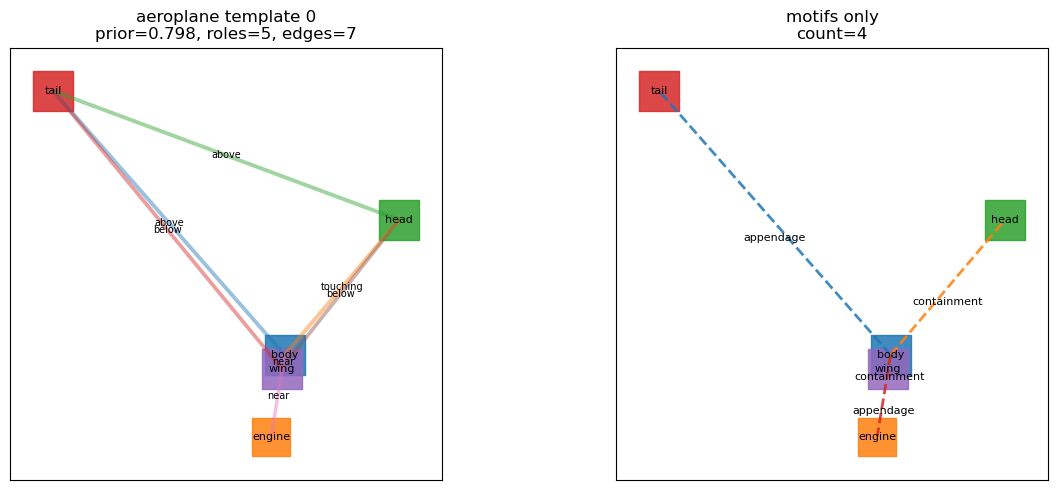

Top roles for aeroplane


,part_idx,part,role_prior,required
2,5,head,0.999735,True
3,10,tail,0.999312,True
0,0,body,0.995199,True
4,12,wing,0.957305,True
1,1,engine,0.877105,True


Template edges for aeroplane


,edge_idx,part_i_idx,part_i,part_j_idx,part_j,support,information_gain,relation_type,top_template_channel,top_template_channel_strength,dx,dy,dist
0,0,0,body,10,tail,0.995283,0.298491,lateral-or-appendage,above,0.270478,-0.024166,-0.270478,0.576620
1,1,0,body,5,head,0.995283,0.262449,attached-to-body,touching,0.280181,0.011746,-0.150520,0.466916
2,2,5,head,10,tail,1.000000,0.219076,axis/extremity,above,0.142106,-0.039056,-0.142106,0.867248
3,5,10,tail,12,wing,0.957547,0.144652,generic-spatial,below,0.293931,0.032846,0.293931,0.478678
4,3,0,body,12,wing,0.952830,0.107730,lateral-or-appendage,near,0.394746,-0.002435,0.015382,0.232378
5,4,5,head,12,wing,0.957547,0.076874,anchor-bond,below,0.153477,-0.018409,0.153477,0.540316
6,6,0,body,1,engine,0.872642,0.002464,attached-to-body,near,0.240697,-0.001583,0.086074,0.356055


Motifs for aeroplane


,motif_idx,part_i_idx,part_i,part_j_idx,part_j,motif_type,support
0,0,0,body,10,tail,appendage,0.995283
1,1,0,body,5,head,containment,0.995283
2,2,0,body,12,wing,containment,0.952830
3,3,0,body,1,engine,appendage,0.872642


[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/006_hkg_class_templates_grid_bird.png


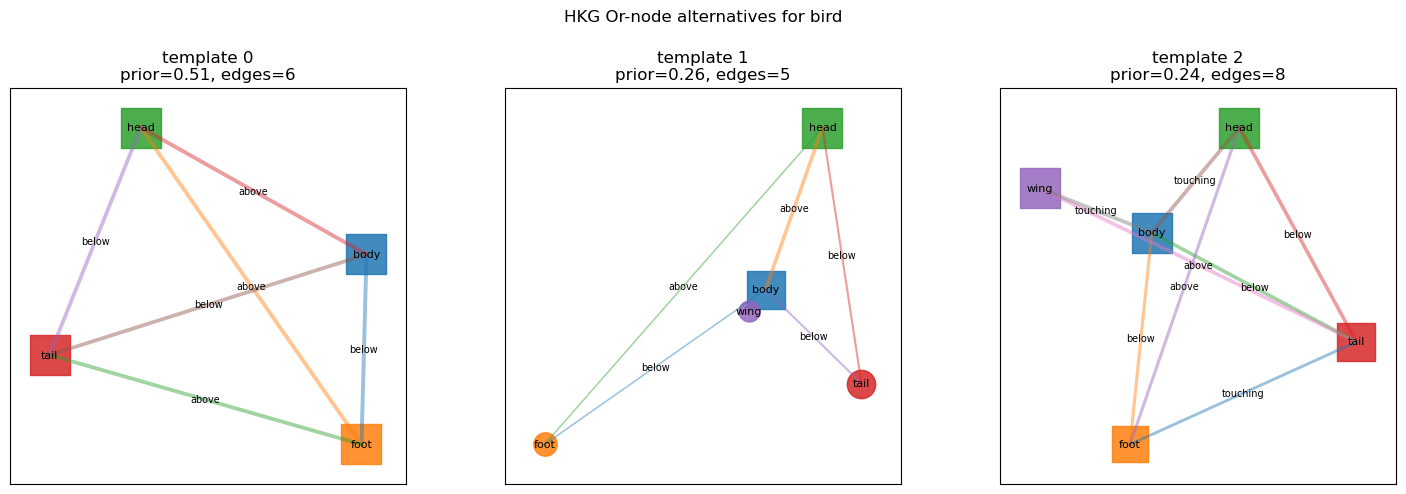

[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/007_hkg_template_configuration_bird.png


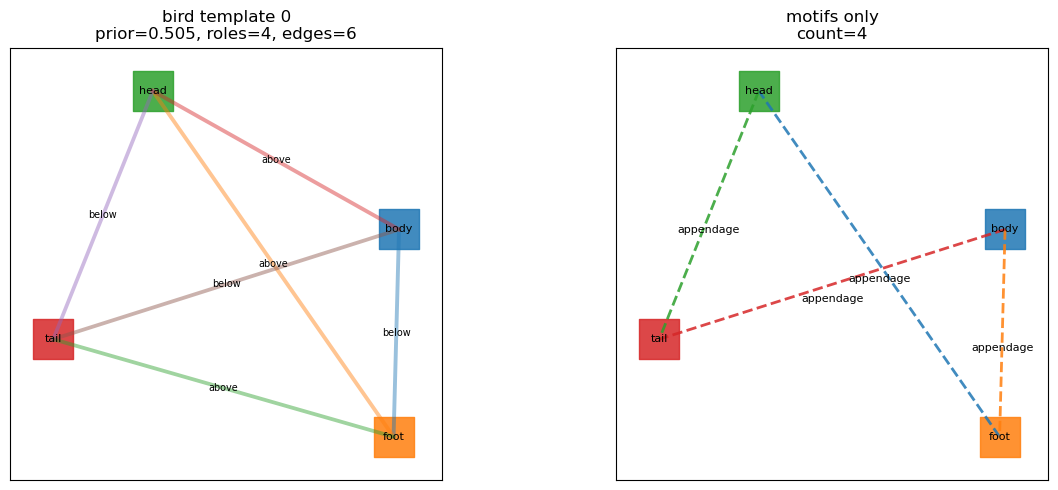

Top roles for bird


,part_idx,part,role_prior,required
2,5,head,0.999997,True
1,3,foot,0.999723,True
0,0,body,0.998972,True
3,10,tail,0.961030,True


Template edges for bird


,edge_idx,part_i_idx,part_i,part_j_idx,part_j,support,information_gain,relation_type,top_template_channel,top_template_channel_strength,dx,dy,dist
0,43,0,body,3,foot,0.999005,0.728948,support/attached-to-body,below,0.420568,-0.000562,0.420568,0.446516
1,44,3,foot,5,head,1.000000,0.521253,axis/extremity,above,0.628855,-0.008827,-0.628855,0.764487
2,46,3,foot,10,tail,0.961194,0.289871,generic-spatial,above,0.211570,-0.008329,-0.211570,0.662035
3,45,0,body,5,head,0.999005,0.135335,attached-to-body,above,0.334845,-0.008121,-0.334845,0.509042
4,47,5,head,10,tail,0.961194,0.057132,axis/extremity,below,0.487155,-0.007751,0.487155,0.831642
5,48,0,body,10,tail,0.960199,0.037796,lateral-or-appendage,below,0.240631,-0.007993,0.240631,0.516872


Motifs for bird


,motif_idx,part_i_idx,part_i,part_j_idx,part_j,motif_type,support
0,31,3,foot,5,head,appendage,1.000000
1,30,0,body,3,foot,appendage,0.999005
2,32,5,head,10,tail,appendage,0.961194
3,33,0,body,10,tail,appendage,0.960199


In [6]:
template_quality = summarize_template_structure_quality(kg)
print("Template structure quality, densest templates first")
display(template_quality.sort_values(["edge_count", "motif_count"], ascending=False).head(20))

# Pick a few classes present in the run. Edit this list if you want to inspect specific classes.
classes_to_show = [name for name in ["car", "aeroplane", "bird"] if name in schema.obj_names]
if not classes_to_show:
    classes_to_show = schema.obj_names[:3]

for cname in classes_to_show:
    fig = plot_hkg_class_templates_grid(kg, cname, max_edges=8)
    save_figure(fig, f"hkg_class_templates_grid_{cname}", subdir="hkg_templates")
    plt.show()
    fig, tables = plot_hkg_template_configuration(kg, cname)
    save_figure(fig, f"hkg_template_configuration_{cname}", subdir="hkg_templates")
    plt.show()
    print(f"Top roles for {cname}")
    display(tables["roles"].head(12))
    print(f"Template edges for {cname}")
    display(tables["edges"].head(12))
    print(f"Motifs for {cname}")
    display(tables["motifs"].head(12))

## 4. Visualize Stage-1 intermediate outputs

Each row shows the raw image, GT union mask, predicted support, top predicted part-mask union, and top presence scores. This is the first check before trusting Stage 2: bad masks or hallucinated presence will propagate into the parse graph.

[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/stage1_samples/008_stage1_sample_00.png


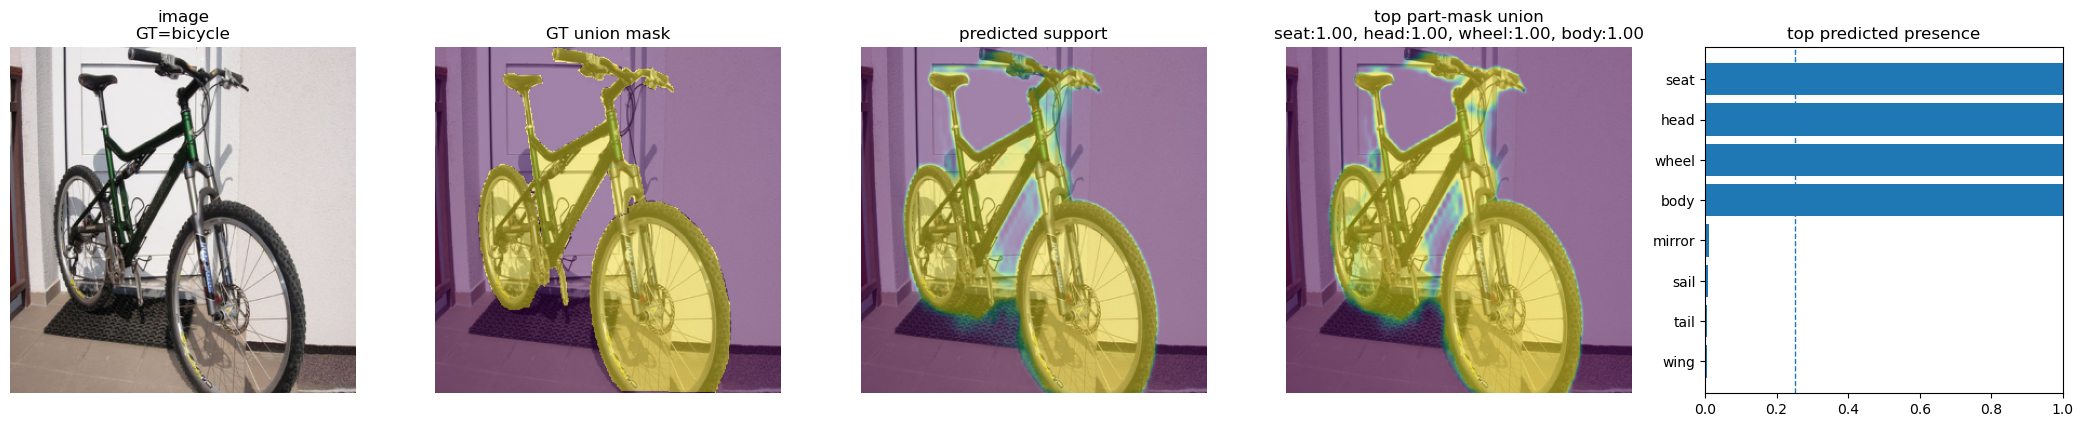

[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/stage1_samples/009_stage1_sample_01.png


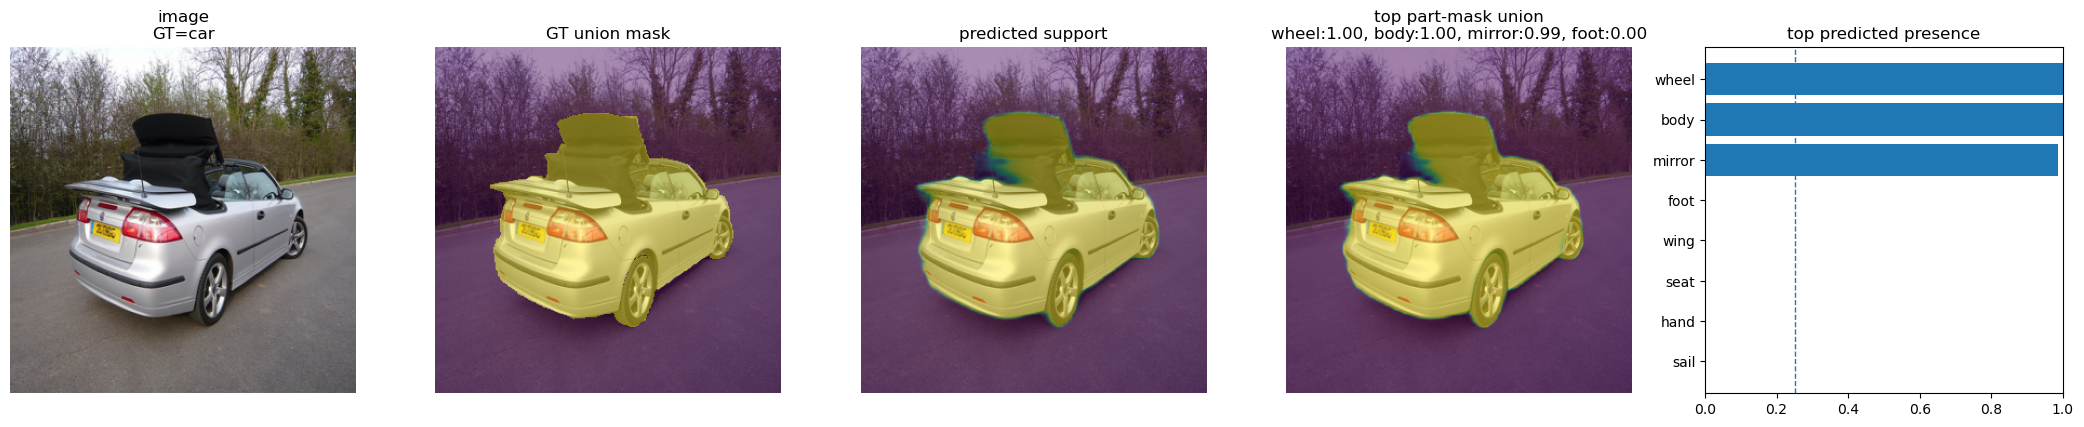

[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/stage1_samples/010_stage1_sample_02.png


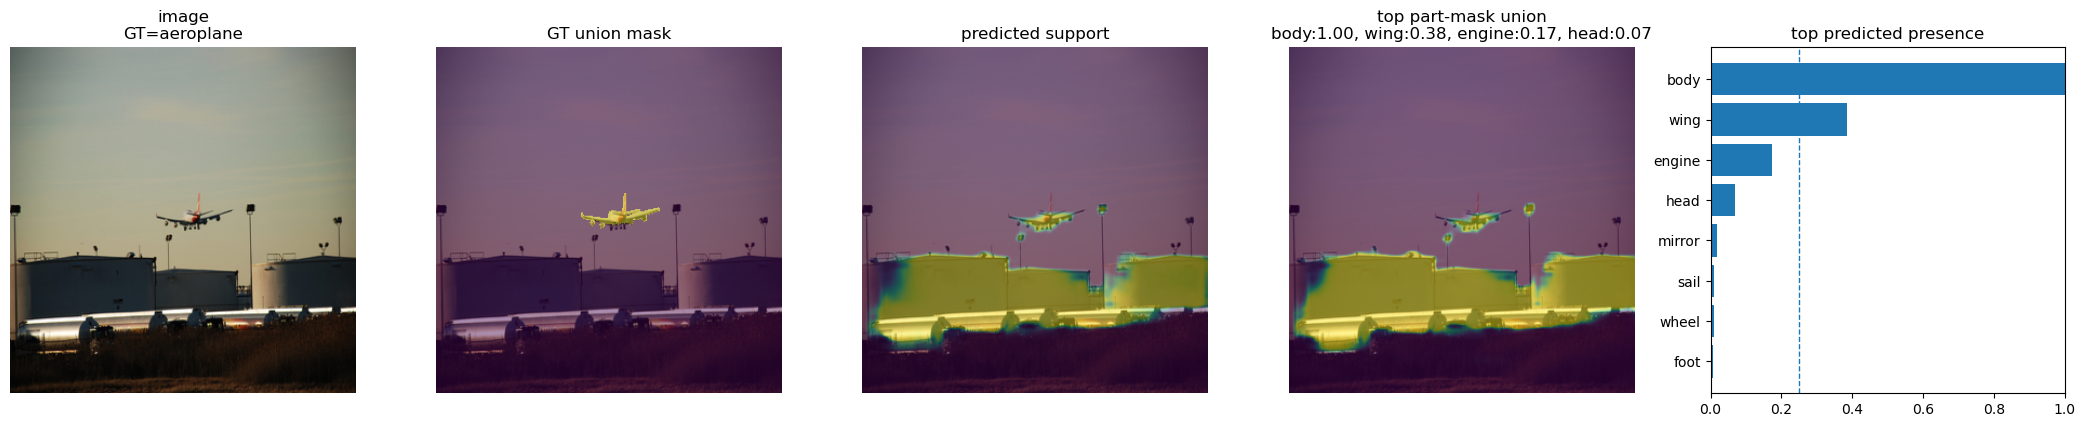

[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/stage1_samples/011_stage1_individual_part_masks_sample_00.png


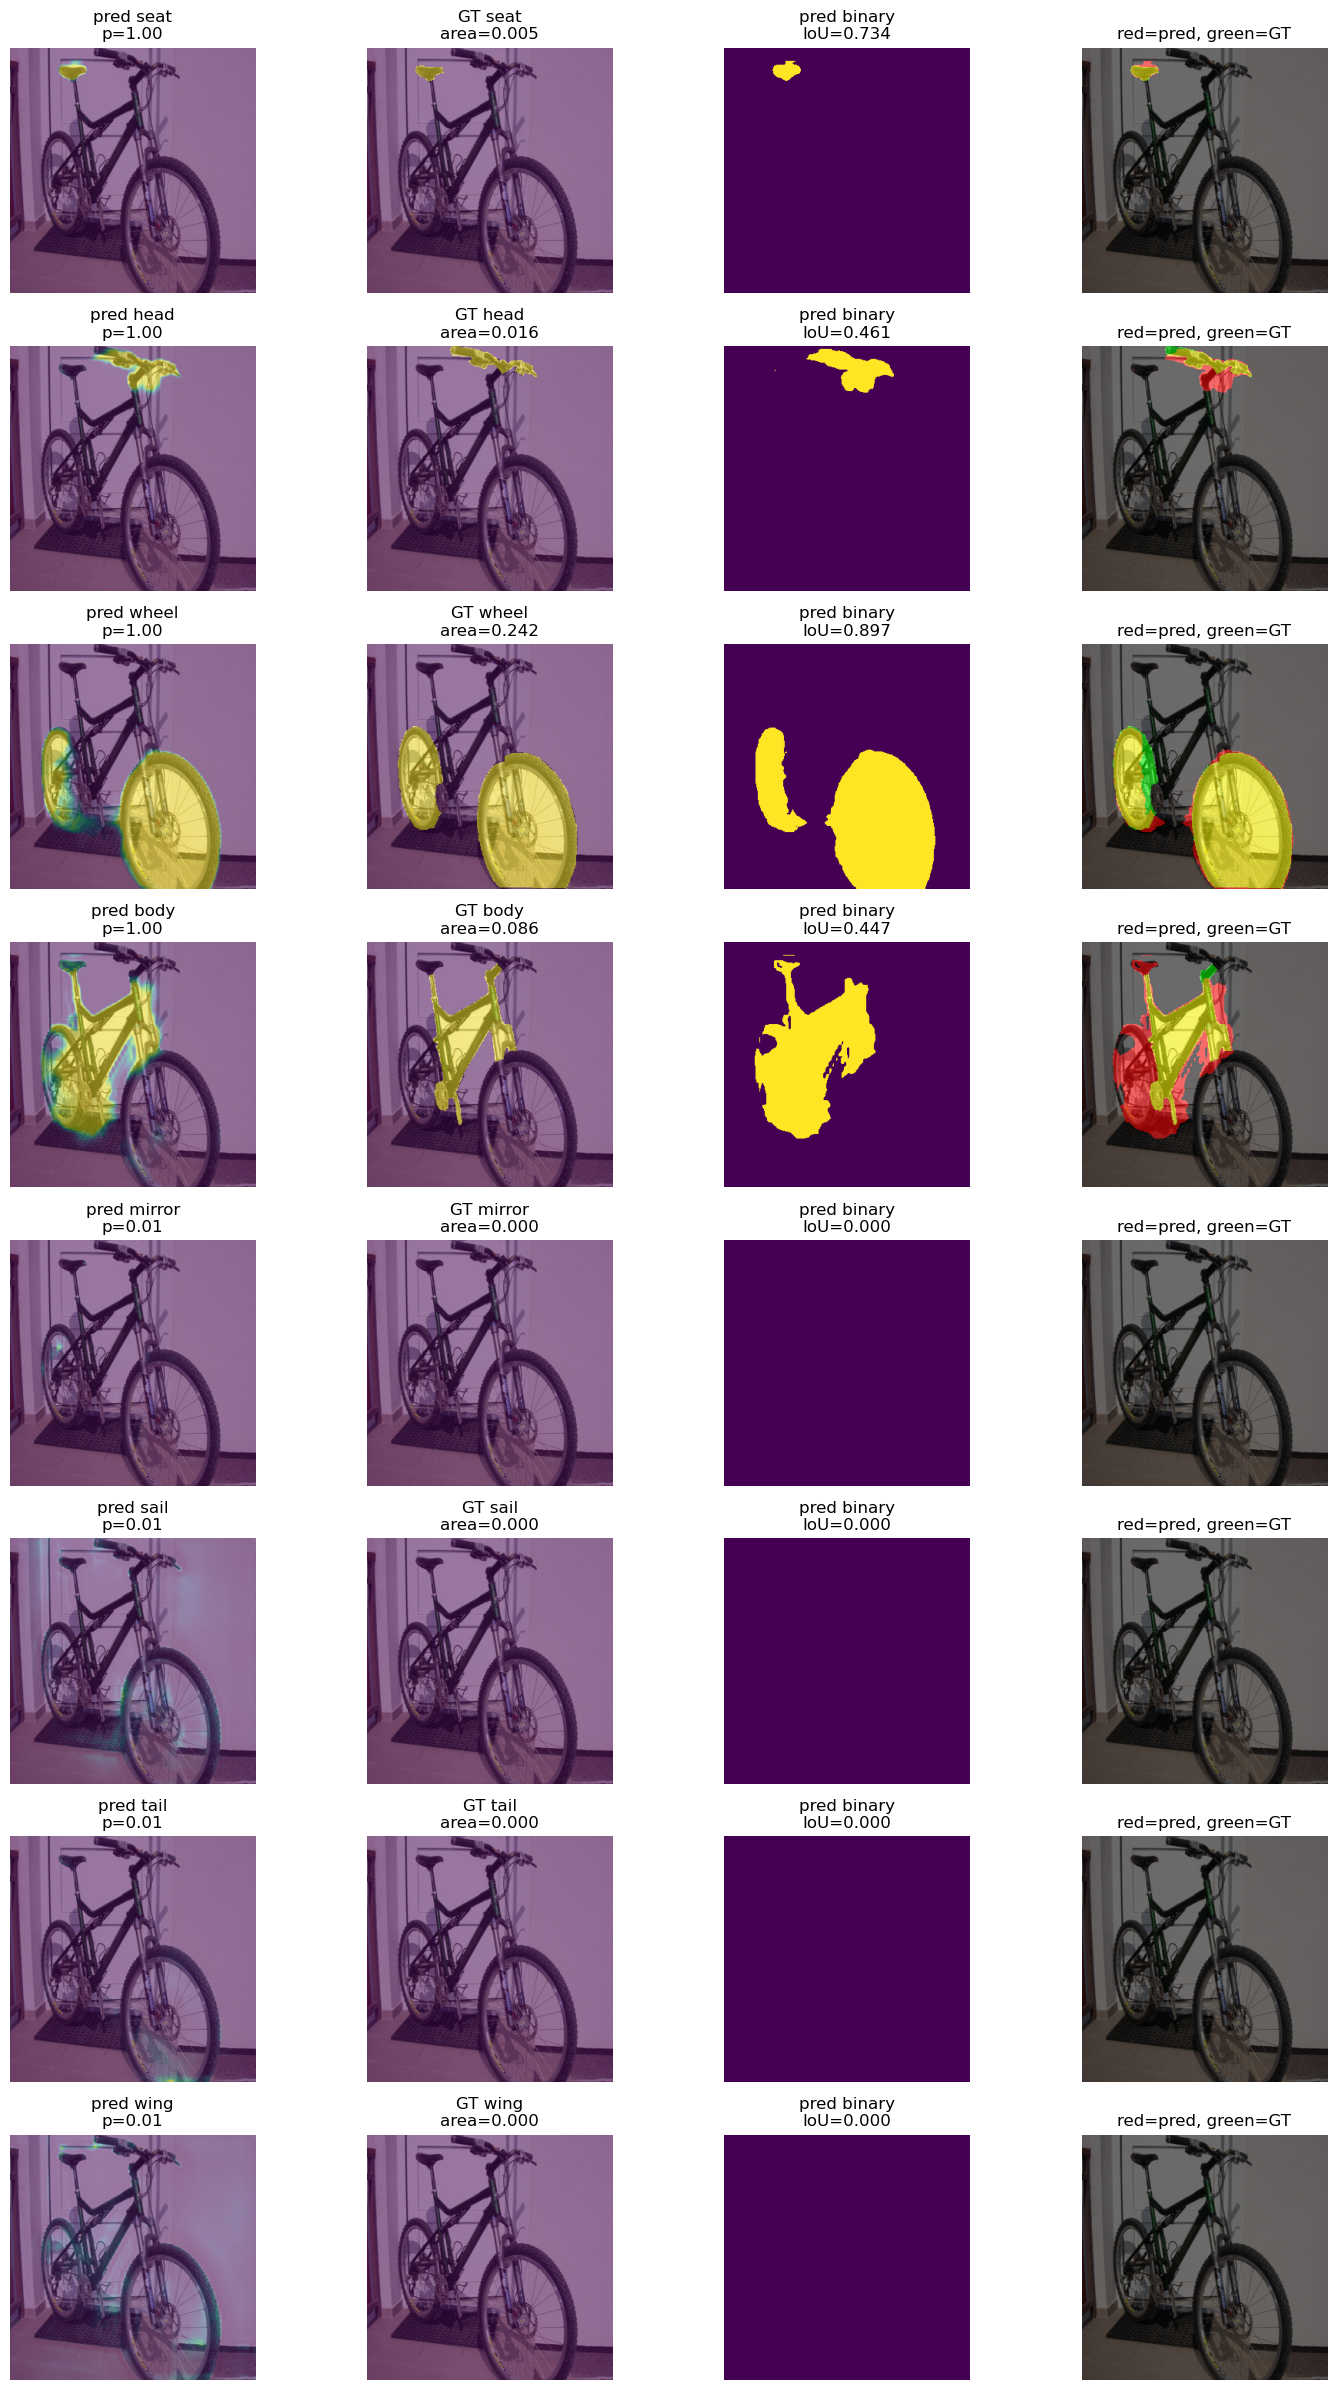

In [7]:
batch = next(iter(diag_loader))
for i in range(min(VIS_SAMPLES, batch["image"].shape[0])):
    fig = plot_stage1_sample(stage1, batch, index=i, top_parts=8, mask_threshold=MASK_THRESHOLD)
    save_figure(fig, f"stage1_sample_{i:02d}", subdir="stage1_samples")
    plt.show()
# Direct per-part GT/predicted masks for the first visualized sample.
# This reveals whether part channels overlap or collapse into object masks.
fig = plot_stage1_part_detail(stage1, batch, index=0, top_parts=8, mask_threshold=MASK_THRESHOLD)
save_figure(fig, "stage1_individual_part_masks_sample_00", subdir="stage1_samples")
plt.show()


## 5. Stage-1 statistical audit

Important columns:

- `iou`, `dice`: segmentation quality for each functional part.
- `presence_f1`: presence/absence quality for each part.
- `hallucination_rate`: part predicted present when absent in GT.
- `miss_rate`: GT-present part not predicted present.

Sort by these columns to find fragile parts such as small or thin structures.

In [8]:
stage1_summary, stage1_per_part = compute_stage1_statistics(
    stage1,
    diag_loader,
    device=device,
    mask_threshold=MASK_THRESHOLD,
    presence_threshold=PRESENCE_THRESHOLD,
    max_batches=MAX_BATCHES,
)
print("Stage-1 summary")
display(stage1_summary)
print("Worst parts by IoU")
display(stage1_per_part.head(15))
print("Worst parts by hallucination rate")
display(stage1_per_part.sort_values("hallucination_rate", ascending=False).head(15))

Stage-1 summary


,n_samples,mIoU,mean_dice,mean_presence_precision,mean_presence_recall,mean_presence_f1,mean_hallucination_rate,mean_miss_rate,valid_role_mass,invalid_role_mass
0,88,0.488084,0.629945,0.799505,0.919183,0.853558,0.141562,0.080817,0.059587,0.001541


Worst parts by IoU


,part,iou,dice,presence_precision,presence_recall,presence_f1,hallucination_rate,miss_rate,gt_presence_rate,mean_pred_presence,pred_pixels,gt_pixels
6,mirror,0.169192,0.289417,0.857143,1.000000,0.923076,0.012195,0.000000,0.068182,0.063946,1303.0,2864.0
1,engine,0.269526,0.424609,0.888889,1.000000,0.941176,0.012500,0.000000,0.090909,0.090364,12860.0,9782.0
12,wing,0.309983,0.473263,0.692308,0.818182,0.749999,0.051948,0.181818,0.125000,0.123240,50224.0,32432.0
9,seat,0.318787,0.483455,0.666667,0.666667,0.666666,0.024390,0.333333,0.068182,0.057566,1571.0,2388.0
4,hand,0.339585,0.507000,0.833333,0.833333,0.833333,0.012195,0.166667,0.068182,0.053787,29283.0,19143.0
10,tail,0.406855,0.578389,0.611111,0.814815,0.698412,0.229508,0.185185,0.306818,0.340160,50292.0,49326.0
3,foot,0.423643,0.595154,0.777778,1.000000,0.875000,0.133333,0.000000,0.318182,0.379499,157454.0,112809.0
2,fin,0.430230,0.601624,0.857143,1.000000,0.923076,0.012195,0.000000,0.068182,0.070552,10449.0,13197.0
0,body,0.702562,0.825300,0.965909,1.000000,0.982659,1.000000,0.000000,0.965909,0.989773,1391459.0,1122161.0
5,head,0.706356,0.827911,0.878788,0.983051,0.927999,0.275862,0.016949,0.670455,0.717029,422635.0,372682.0


Worst parts by hallucination rate


,part,iou,dice,presence_precision,presence_recall,presence_f1,hallucination_rate,miss_rate,gt_presence_rate,mean_pred_presence,pred_pixels,gt_pixels
0,body,0.702562,0.825300,0.965909,1.000000,0.982659,1.000000,0.000000,0.965909,0.989773,1391459.0,1122161.0
5,head,0.706356,0.827911,0.878788,0.983051,0.927999,0.275862,0.016949,0.670455,0.717029,422635.0,372682.0
10,tail,0.406855,0.578389,0.611111,0.814815,0.698412,0.229508,0.185185,0.306818,0.340160,50292.0,49326.0
3,foot,0.423643,0.595154,0.777778,1.000000,0.875000,0.133333,0.000000,0.318182,0.379499,157454.0,112809.0
12,wing,0.309983,0.473263,0.692308,0.818182,0.749999,0.051948,0.181818,0.125000,0.123240,50224.0,32432.0
7,mouth,0.757733,0.862171,0.625000,0.833333,0.714285,0.036585,0.166667,0.068182,0.067226,12332.0,11081.0
11,wheel,0.737970,0.849232,0.882353,1.000000,0.937499,0.027397,0.000000,0.170455,0.173997,46255.0,44434.0
9,seat,0.318787,0.483455,0.666667,0.666667,0.666666,0.024390,0.333333,0.068182,0.057566,1571.0,2388.0
1,engine,0.269526,0.424609,0.888889,1.000000,0.941176,0.012500,0.000000,0.090909,0.090364,12860.0,9782.0
4,hand,0.339585,0.507000,0.833333,0.833333,0.833333,0.012195,0.166667,0.068182,0.053787,29283.0,19143.0


[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/012_stage1_worst_parts.png


PosixPath('/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/012_stage1_worst_parts.png')

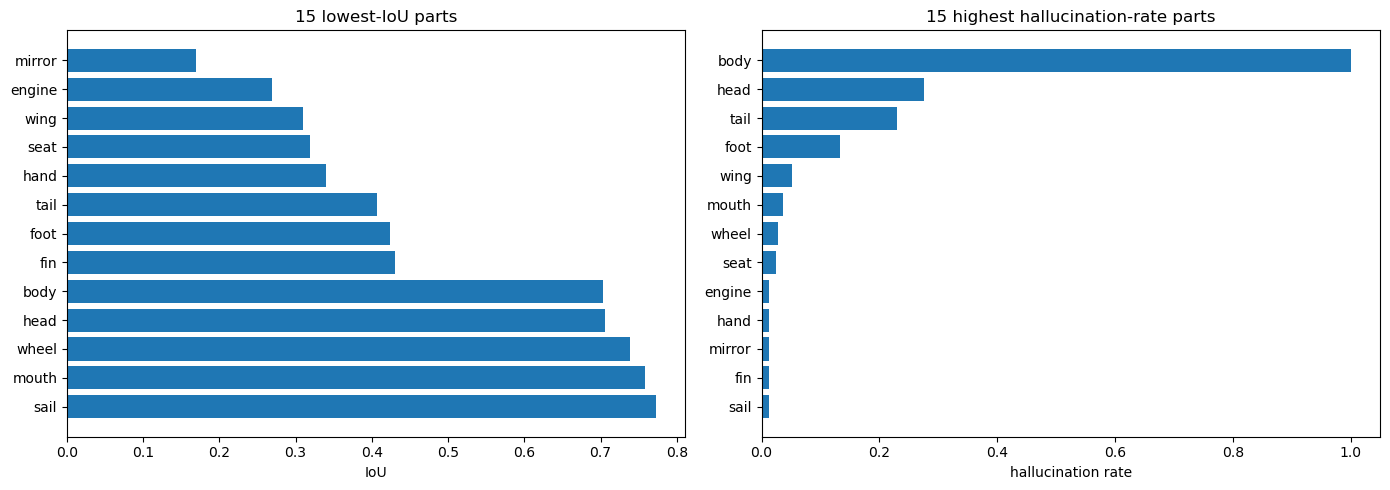

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
worst_iou = stage1_per_part.sort_values("iou").head(15).iloc[::-1]
axes[0].barh(worst_iou["part"], worst_iou["iou"])
axes[0].set_title("15 lowest-IoU parts")
axes[0].set_xlabel("IoU")

worst_hall = stage1_per_part.sort_values("hallucination_rate", ascending=False).head(15).iloc[::-1]
axes[1].barh(worst_hall["part"], worst_hall["hallucination_rate"])
axes[1].set_title("15 highest hallucination-rate parts")
axes[1].set_xlabel("hallucination rate")
fig.tight_layout()
save_figure(fig, "stage1_worst_parts")

## 6. Stage-2 branch-level statistical audit

The final classifier is compared against its internal branches:

- `base`: part-token baseline classifier.
- `hkg`: full HKG parse score before fusion.
- `node`: node-only branch.
- `edge`: edge-only branch.
- `motif`: motif-only branch.
- `final`: calibrated fusion.

The `final_vs_base_delta` row reports final accuracy minus base accuracy, plus rescue and damage rates.

In [10]:
pred_df = collect_stage2_predictions(
    model,
    diag_loader,
    device=device,
    max_batches=MAX_BATCHES,
    presence_threshold=PRESENCE_THRESHOLD,
    enable_edges=True,
)
branch_summary, class_summary = summarize_classification(pred_df, schema)
print("Branch summary")
display(branch_summary)
print("Class summary, lowest final accuracy first")
display(class_summary.sort_values("acc_final").head(20))
print("Per-image predictions")
display(pred_df.head(10))

Branch summary


,branch,n,accuracy,macro_accuracy,mean_confidence,ECE_15bins,mean_true_probability,mean_true_rank,rescue_rate,damage_rate
0,final,88,0.954545,0.954545,0.975347,0.041629,0.935335,1.079545,NaN,NaN
1,base,88,0.943182,0.943182,0.960068,0.070222,0.913528,1.079545,NaN,NaN
2,hkg,88,0.943182,0.943182,0.954547,0.067086,0.911567,1.159091,NaN,NaN
3,node,88,0.943182,0.943182,0.759465,0.183717,0.736452,1.159091,NaN,NaN
4,edge,88,0.000000,0.000000,0.094282,0.094282,0.082105,10.477273,NaN,NaN
5,motif,88,0.772727,0.772727,0.186293,0.586434,0.177644,1.636364,NaN,NaN
6,final_vs_base_delta,88,0.011364,NaN,NaN,NaN,NaN,NaN,0.011364,0.0


Class summary, lowest final accuracy first


,class_idx,class,support,acc_final,acc_base,acc_hkg,acc_node,acc_edge,acc_motif,rescue_rate,damage_rate,mean_active_part_count
0,0,aeroplane,8,0.875,0.875,0.875,0.875,0.0,1.000,0.000,0.0,4.875
2,2,biped,8,0.875,0.875,0.875,0.875,0.0,0.875,0.000,0.0,4.125
7,7,fish,8,0.875,0.875,0.875,0.875,0.0,0.625,0.000,0.0,4.000
5,5,bottle,8,0.875,0.750,0.875,0.875,0.0,0.000,0.125,0.0,2.625
3,3,bird,8,1.000,1.000,1.000,1.000,0.0,1.000,0.000,0.0,4.375
1,1,bicycle,8,1.000,1.000,1.000,1.000,0.0,1.000,0.000,0.0,4.125
4,4,boat,8,1.000,1.000,0.875,0.875,0.0,0.000,0.000,0.0,2.500
6,6,car,8,1.000,1.000,1.000,1.000,0.0,1.000,0.000,0.0,2.750
8,8,quadruped,8,1.000,1.000,1.000,1.000,0.0,1.000,0.000,0.0,3.375
9,9,reptile,8,1.000,1.000,1.000,1.000,0.0,1.000,0.000,0.0,3.500


Per-image predictions


,sample_index,batch_index,batch_row,image_id,path,gt_idx,gt,active_part_count,mean_part_presence,max_part_presence,active_parts_top,pred_final_idx,pred_final,correct_final,conf_final,prob_true_final,logit_true_final,margin_final,rank_true_final,pred_base_idx,pred_base,correct_base,conf_base,prob_true_base,logit_true_base,margin_base,rank_true_base,pred_hkg_idx,pred_hkg,correct_hkg,conf_hkg,prob_true_hkg,logit_true_hkg,margin_hkg,rank_true_hkg,pred_node_idx,pred_node,correct_node,conf_node,prob_true_node,logit_true_node,margin_node,rank_true_node,pred_edge_idx,pred_edge,correct_edge,conf_edge,prob_true_edge,logit_true_edge,margin_edge,rank_true_edge,pred_motif_idx,pred_motif,correct_motif,conf_motif,prob_true_motif,logit_true_motif,margin_motif,rank_true_motif,best_template_pred,best_template_gt,template_score_pred,template_score_gt,rescued_by_final_vs_base,damaged_by_final_vs_base
0,0,0,0,1202,../../full_hyco/PartImageNet/images/val/n03792782_15059.JPEG,1,bicycle,4,0.310781,0.999975,"seat:1.00, head:1.00, wheel:1.00, body:1.00",1,bicycle,True,0.999925,0.999925,12.548551,10.528849,1,1,bicycle,True,0.998123,0.998123,9.367043,7.073015,1,1,bicycle,True,0.999955,0.999955,12.503367,10.250394,1,1,bicycle,True,0.961269,0.961269,5.217810,4.262109,1,7,fish,False,0.095737,0.085871,-0.052355,0.000322,10,1,bicycle,True,0.129229,0.129229,0.359416,0.340016,1,0,0,10.105770,10.105770,False,False
1,1,0,1,5,../../full_hyco/PartImageNet/images/val/n03100240_8854.JPEG,6,car,3,0.230185,0.999938,"wheel:1.00, body:1.00, mirror:0.99",6,car,True,0.999974,0.999974,14.213066,10.907867,1,6,car,True,0.999475,0.999475,11.127629,8.179490,1,6,car,True,0.999989,0.999989,13.444502,11.802896,1,6,car,True,0.965782,0.965782,5.283140,4.521685,1,9,reptile,False,0.091370,0.089150,-0.019514,0.000008,11,6,car,True,0.356251,0.356251,1.557641,1.596391,1,0,0,10.977397,10.977397,False,False
2,2,0,2,1170,../../full_hyco/PartImageNet/images/val/n02690373_1075.JPEG,0,aeroplane,3,0.129000,0.999870,"body:1.00, wing:0.38, engine:0.17",4,boat,False,0.907758,0.089101,6.833972,2.321209,2,4,boat,False,0.887984,0.106715,6.260767,2.118796,2,4,boat,False,0.567622,0.256228,2.473843,0.795389,2,4,boat,False,0.289023,0.199372,1.060034,0.371332,2,9,reptile,False,0.098911,0.073926,-0.201227,0.000028,11,0,aeroplane,True,0.095720,0.095720,0.051740,0.040019,1,0,0,1.519339,0.415967,False,False
3,3,0,3,398,../../full_hyco/PartImageNet/images/val/n02823428_6229.JPEG,5,bottle,3,0.204904,0.998190,"body:1.00, mouth:1.00, head:0.51",5,bottle,True,0.559374,0.559374,6.824247,0.253084,1,3,bird,False,0.885098,0.102731,4.565103,2.153581,2,5,bottle,True,0.999201,0.999201,8.750571,8.749491,1,5,bottle,True,0.844922,0.844922,3.670470,3.641113,1,2,biped,False,0.093465,0.087335,-0.039386,0.000025,10,3,bird,False,0.136436,0.089875,-0.001378,0.417443,2,0,0,6.038360,6.038360,True,False
4,4,1,0,1159,../../full_hyco/PartImageNet/images/val/n04552348_10024.JPEG,0,aeroplane,5,0.380203,0.998720,"body:1.00, tail:1.00, head:0.99, engine:0.99, wing:0.90",0,aeroplane,True,0.993177,0.993177,11.438891,5.138360,1,0,aeroplane,True,0.805212,0.805212,7.282133,1.657574,1,0,aeroplane,True,0.999996,0.999996,15.712455,12.732650,1,0,aeroplane,True,0.988732,0.988732,6.582262,5.382214,1,9,reptile,False,0.097108,0.074382,-0.198036,0.002889,11,0,aeroplane,True,0.102703,0.102703,0.123850,0.017490,1,0,0,13.085054,13.085054,False,False
5,5,1,1,426,../../full_hyco/PartImageNet/images/val/n04483307_1642.JPEG,4,boat,2,0.159479,0.999856,"sail:1.00, body:1.00",4,boat,True,0.999968,0.999968,13.769024,11.114308,1,4,boat,True,0.999483,0.999483,11.240979,8.437113,1,4,boat,True,0.999677,0.999677,9.566015,9.409945,1,4,boat,True,0.883392,0.883392,3.966256,3.867261,1,8,quadruped,False,0.091664,0.089981,-0.010222,0.000179,10,0,aeroplane,False,0.091733,0.090906,-0.000028,0.003306,4,0,0,7.432389,7.432389,False,False
6,6,1,2,419,../../full_hyco/PartImageNet/images/val/n04147183_1261.JPEG,4,boat,2,0.097473,0.999992,"body:1.00, sail:0.24",4,boat,True,0.999889,

[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/013_stage2_confusion_matrix_final.png


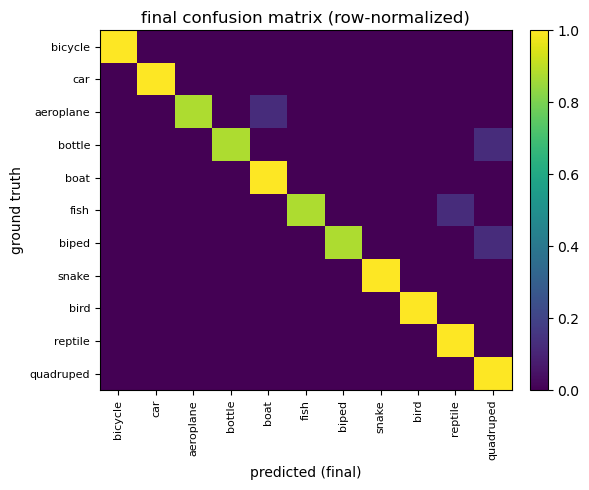

[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/014_stage2_calibration_curve_final.png


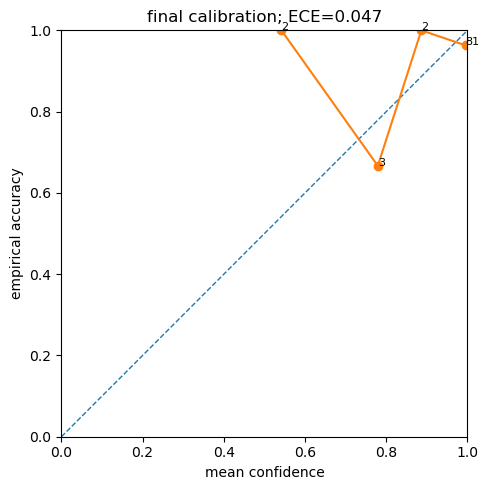

In [11]:
fig = plot_confusion_matrix(pred_df, schema, branch="final", top_classes=30, normalize=True)
save_figure(fig, "stage2_confusion_matrix_final")
plt.show()
fig = plot_calibration_curve(pred_df, branch="final", n_bins=10)
save_figure(fig, "stage2_calibration_curve_final")
plt.show()

## 7. Mine wrong, rescued, and damaged samples

- **Rescued**: base classifier wrong, final fused classifier correct.
- **Damaged**: base classifier correct, final fused classifier wrong.
- **Wrong final**: final fused classifier wrong.

These are the most informative examples for debugging whether the HKG is helping or hurting.

In [12]:
wrong_df = pred_df[~pred_df["correct_final"]].copy()
rescue_df = pred_df[pred_df["rescued_by_final_vs_base"]].copy()
damage_df = pred_df[pred_df["damaged_by_final_vs_base"]].copy()

print(f"wrong_final={len(wrong_df)} rescued={len(rescue_df)} damaged={len(damage_df)}")
print("Rescued examples")
display(rescue_df.head(10))
print("Damaged examples")
display(damage_df.head(10))
print("Wrong final examples")
display(wrong_df.head(10))

wrong_final=4 rescued=1 damaged=0
Rescued examples


,sample_index,batch_index,batch_row,image_id,path,gt_idx,gt,active_part_count,mean_part_presence,max_part_presence,active_parts_top,pred_final_idx,pred_final,correct_final,conf_final,prob_true_final,logit_true_final,margin_final,rank_true_final,pred_base_idx,pred_base,correct_base,conf_base,prob_true_base,logit_true_base,margin_base,rank_true_base,pred_hkg_idx,pred_hkg,correct_hkg,conf_hkg,prob_true_hkg,logit_true_hkg,margin_hkg,rank_true_hkg,pred_node_idx,pred_node,correct_node,conf_node,prob_true_node,logit_true_node,margin_node,rank_true_node,pred_edge_idx,pred_edge,correct_edge,conf_edge,prob_true_edge,logit_true_edge,margin_edge,rank_true_edge,pred_motif_idx,pred_motif,correct_motif,conf_motif,prob_true_motif,logit_true_motif,margin_motif,rank_true_motif,best_template_pred,best_template_gt,template_score_pred,template_score_gt,rescued_by_final_vs_base,damaged_by_final_vs_base
3,3,0,3,398,../../full_hyco/PartImageNet/images/val/n02823428_6229.JPEG,5,bottle,3,0.204904,0.99819,"body:1.00, mouth:1.00, head:0.51",5,bottle,True,0.559374,0.559374,6.824247,0.253084,1,3,bird,False,0.885098,0.102731,4.565103,2.153581,2,5,bottle,True,0.999201,0.999201,8.750571,8.749491,1,5,bottle,True,0.844922,0.844922,3.67047,3.641113,1,2,biped,False,0.093465,0.087335,-0.039386,0.000025,10,3,bird,False,0.136436,0.089875,-0.001378,0.417443,2,0,0,6.03836,6.03836,True,False


Damaged examples


,sample_index,batch_index,batch_row,image_id,path,gt_idx,gt,active_part_count,mean_part_presence,max_part_presence,active_parts_top,pred_final_idx,pred_final,correct_final,conf_final,prob_true_final,logit_true_final,margin_final,rank_true_final,pred_base_idx,pred_base,correct_base,conf_base,prob_true_base,logit_true_base,margin_base,rank_true_base,pred_hkg_idx,pred_hkg,correct_hkg,conf_hkg,prob_true_hkg,logit_true_hkg,margin_hkg,rank_true_hkg,pred_node_idx,pred_node,correct_node,conf_node,prob_true_node,logit_true_node,margin_node,rank_true_node,pred_edge_idx,pred_edge,correct_edge,conf_edge,prob_true_edge,logit_true_edge,margin_edge,rank_true_edge,pred_motif_idx,pred_motif,correct_motif,conf_motif,prob_true_motif,logit_true_motif,margin_motif,rank_true_motif,best_template_pred,best_template_gt,template_score_pred,template_score_gt,rescued_by_final_vs_base,damaged_by_final_vs_base


Wrong final examples


,sample_index,batch_index,batch_row,image_id,path,gt_idx,gt,active_part_count,mean_part_presence,max_part_presence,active_parts_top,pred_final_idx,pred_final,correct_final,conf_final,prob_true_final,logit_true_final,margin_final,rank_true_final,pred_base_idx,pred_base,correct_base,conf_base,prob_true_base,logit_true_base,margin_base,rank_true_base,pred_hkg_idx,pred_hkg,correct_hkg,conf_hkg,prob_true_hkg,logit_true_hkg,margin_hkg,rank_true_hkg,pred_node_idx,pred_node,correct_node,conf_node,prob_true_node,logit_true_node,margin_node,rank_true_node,pred_edge_idx,pred_edge,correct_edge,conf_edge,prob_true_edge,logit_true_edge,margin_edge,rank_true_edge,pred_motif_idx,pred_motif,correct_motif,conf_motif,prob_true_motif,logit_true_motif,margin_motif,rank_true_motif,best_template_pred,best_template_gt,template_score_pred,template_score_gt,rescued_by_final_vs_base,damaged_by_final_vs_base
2,2,0,2,1170,../../full_hyco/PartImageNet/images/val/n02690373_1075.JPEG,0,aeroplane,3,0.129000,0.999870,"body:1.00, wing:0.38, engine:0.17",4,boat,False,0.907758,0.089101,6.833972,2.321209,2,4,boat,False,0.887984,0.106715,6.260767,2.118796,2,4,boat,False,0.567622,0.256228,2.473843,0.795389,2,4,boat,False,0.289023,0.199372,1.060034,0.371332,2,9,reptile,False,0.098911,0.073926,-0.201227,0.000028,11,0,aeroplane,True,0.095720,0.095720,0.051740,0.040019,1,0,0,1.519339,0.415967,False,False
19,19,4,3,183,../../full_hyco/PartImageNet/images/val/n02490219_4912.JPEG,2,biped,3,0.230333,0.999995,"head:1.00, body:1.00, foot:0.96",8,quadruped,False,0.992631,0.000307,2.637163,4.969266,3,8,quadruped,False,0.967191,0.001410,2.374742,3.463971,3,8,quadruped,False,0.996715,0.000655,0.742198,6.894555,4,8,quadruped,False,0.732174,0.044319,0.361851,2.645519,4,7,fish,False,0.094081,0.075063,-0.189681,0.000368,11,8,quadruped,False,0.230377,0.076865,-0.099339,0.990897,6,0,0,6.485140,-1.018229,False,False
45,45,11,1,382,../../full_hyco/PartImageNet/images/val/n04591713_5290.JPEG,5,bottle,3,0.226343,0.996935,"head:1.00, body:1.00, foot:0.82",8,quadruped,False,0.991735,0.001965,2.078741,5.777246,3,8,quadruped,False,0.965392,0.011359,2.301228,4.442547,2,8,quadruped,False,0.990988,0.000287,-1.243479,6.009145,8,8,quadruped,False,0.662320,0.024260,-0.491324,2.411923,8,0,aeroplane,False,0.097557,0.083645,-0.080681,0.003244,9,8,quadruped,False,0.124937,0.089818,-0.005126,0.242709,4,0,0,5.226182,-3.234634,False,False
63,63,15,3,631,../../full_hyco/PartImageNet/images/val/n02655020_3635.JPEG,7,fish,3,0.217233,0.999812,"head:1.00, body:0.93, foot:0.88",9,reptile,False,0.776587,0.056297,4.119066,1.893449,3,9,reptile,False,0.692866,0.080735,3.712851,1.575085,3,9,reptile,False,0.650822,0.081847,1.605005,1.443772,3,9,reptile,False,0.311220,0.125185,0.666049,0.634820,3,0,aeroplane,False,0.098199,0.072924,-0.216283,0.002272,11,9,reptile,False,0.231507,0.073065,-0.147771,0.925005,7,0,1,1.513855,0.282647,False,False


## 8. Visualize one Stage-2 parse graph

Choose `PICK_MODE` from `"wrong"`, `"damage"`, `"rescue"`, or `"index"`. For `"index"`, set `PICK_INDEX` to a row in `pred_df`.

The plot shows active Stage-1 part masks, the selected HKG template edges, and branch logits for the GT class. The tables below expose the parse graph internals.

[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/stage2_parse/015_stage2_parse_overlay_selected.png


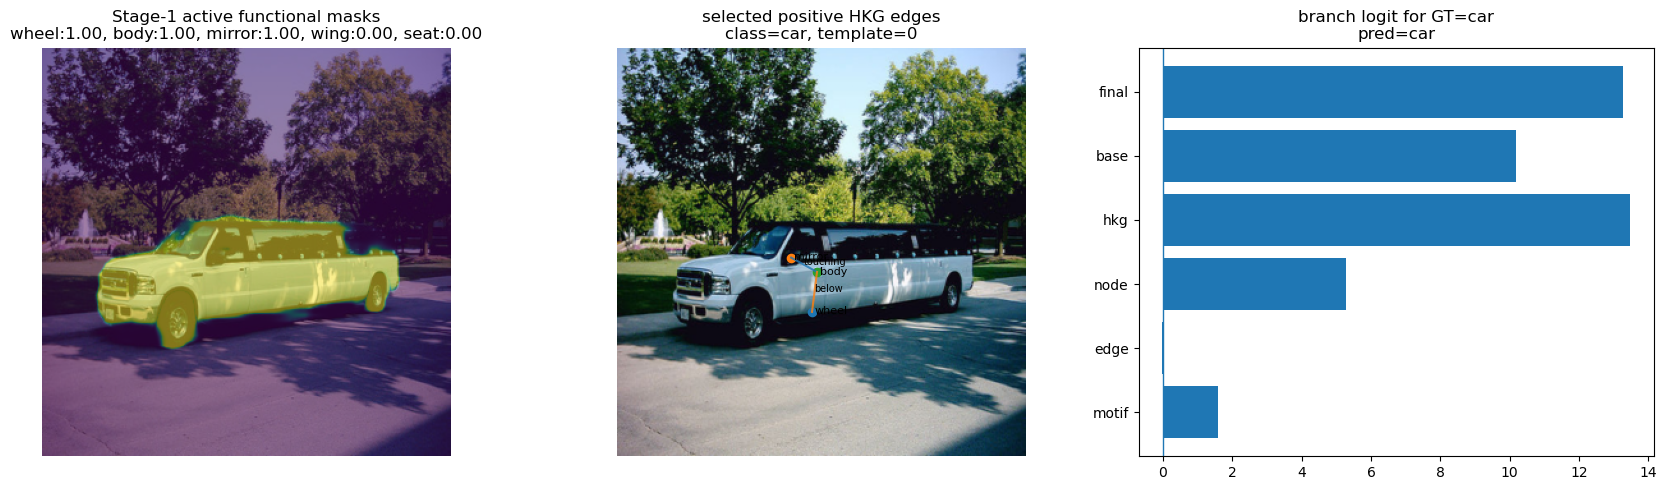

Parse summary


,gt_idx,gt,pred_idx,pred,explained_class_idx,explained_class,template,final_top5,base_pred,hkg_pred,hkg_logit_explained,node_logit_explained,edge_logit_explained,motif_logit_explained
0,6,car,6,car,6,car,0,"car:13.28, bicycle:2.42, biped:1.80, quadruped:1.21, boat:1.18",car,car,13.477707,5.287512,-0.027747,1.597122


Node contributions


,part_idx,part,role_idx,part_presence,role_presence,obs_presence,template_role_prior,required,pmi,appearance_similarity,node_evidence,missing_penalty,conflict_penalty,spurious_penalty,node_contribution
11,11,wheel,25,0.999972,0.999999,0.999999,9.999304e-01,True,2.118253,0.995083,1.736349e+00,3.754831e-07,0.029026,0.000000,4.032012
6,6,mirror,24,0.998401,0.912956,0.998401,9.997224e-01,True,2.386620,0.980043,1.811156e+00,5.593951e-04,0.115551,0.000000,4.003018
0,0,body,23,0.999946,0.999943,0.999946,9.991595e-01,True,0.035726,0.975788,9.873814e-01,1.886390e-05,0.000372,0.000000,2.330876
7,7,mouth,-1,0.000077,0.000000,0.000100,4.463746e-07,False,-3.448192,-0.491047,-2.813537e-10,0.000000e+00,0.000027,0.000019,-0.000110
2,2,fin,-1,0.000112,0.000000,0.000112,4.463746e-07,False,-4.617355,-0.516028,-3.341047e-10,0.000000e+00,0.000039,0.000028,-0.000159
1,1,engine,-1,0.000118,0.000000,0.000118,4.463746e-07,False,-3.002452,-0.673241,-3.292373e-10,0.000000e+00,0.000041,0.000030,-0.000167
10,10,tail,-1,0.000187,0.000000,0.000187,4.463746e-07,False,-5.000000,-0.696095,-5.630669e-10,0.000000e+00,0.000065,0.000047,-0.000265
5,5,head,-1,0.000237,0.000000,0.000237,4.463746e-07,False,-5.000000,-0.798843,-7.105390e-10,0.000000e+00,0.000083,0.000059,-0.000335
3,3,foot,-1,0.000264,0.000000,0.000264,4.463746e-07,False,-5.000000,-0.611408,-7.636349e-10,0.000000e+00,0.000092,0.000066,-0.000374
4,4,hand,-1,0.000269,0.000000,0.000269,4.463746e-07,False,-5.000000,-0.635797,-7.807428e-10,0.000000e+00,0.000094,0.000067,-0.000381


Edge contributions


,edge_idx,part_i_idx,part_i,part_j_idx,part_j,role_i,role_j,relation_type,support,information_gain,strength,ll_template,ll_global,llr,edge_score_mode,edge_used_by_model,edge_draw_score,edge_contribution,top_observed_channel,top_observed_channel_strength,top_template_channel,top_template_channel_strength,obs_dx,template_dx,resid_z_dx,obs_dy,template_dy,resid_z_dy,obs_dist,template_dist,resid_z_dist,obs_area_i,template_area_i,resid_z_area_i,obs_area_j,template_area_j,resid_z_area_j,obs_log_area_ratio,template_log_area_ratio,resid_z_log_area_ratio,obs_bbox_w_i,template_bbox_w_i,resid_z_bbox_w_i,obs_bbox_h_i,template_bbox_h_i,resid_z_bbox_h_i,obs_bbox_w_j,template_bbox_w_j,resid_z_bbox_w_j,obs_bbox_h_j,template_bbox_h_j,resid_z_bbox_h_j,obs_iou,template_iou,resid_z_iou,obs_contact,template_contact,resid_z_contact,obs_contain_i_in_j,template_contain_i_in_j,resid_z_contain_i_in_j,obs_contain_j_in_i,template_contain_j_in_i,resid_z_contain_j_in_i
1,65,0,body,6,mirror,23,24,attached-to-body,0.99916,0.000492,0.955460,2.146190,2.130162,0.016028,template_fit,-0.106562,0.429291,-0.001070,touching,1.000000,touching,0.779891,-0.085807,0.011697,-0.368123,-0.133848,-0.139455,0.05319,0.158994,0.287449,-0.951448,0.674889,0.681500,-0.066713,0.006507,0.008757,-0.071143,4.641477,4.561786,0.093653,1.0,0.996694,0.104559,1.000000,0.999041,0.030333,0.076271,0.214629,-0.551902,0.142857,0.160721,-0.220508,0.009567,0.008227,0.042368,1.000000,0.779891,0.730864,0.009567,0.008260,0.041353,0.992248,0.662371,1.009506
0,64,0,body,11,wheel,23,25,support/attached-to-body,0.99916,0.104555,0.999971,2.034177,1.789149,0.245028,template_fit,-0.322847,0.395968,-0.005237,below,0.300458,below,0.323162,-0.016547,0.007033,-0.142687,0.300458,0.323162,-0.28266,0.300915,0.365265,-0.925996,0.545103,0.631463,-0.843639,0.060748,0.068365,-0.186477,2.194225,2.390003,-0.249460,1.0,0.997007,0.090253,0.807692,0.925270,-2.108116,0.932203,0.671466,1.135087,0.576923,0.434758,1.032002,0.008888,0.014260,-0.169838,0.180416,0.243131,-0.359536,0.009791,0.016103,-0.198061,0.087860,0.165746,-0.519772


Motif contributions


,motif_idx,part_i,part_j,motif_type,support,strength,motif_value,learned_motif_weight,motif_contribution
1,44,body,mirror,containment,0.99916,0.955460,0.992248,2.944726,0.535043
0,43,body,wheel,appendage,0.99916,0.999971,0.300094,3.013671,0.173321


In [13]:
PICK_MODE = "wrong"   # "wrong", "damage", "rescue", or "index"
PICK_INDEX = 0
EXPLAIN_GT_INSTEAD_OF_PRED = False

def get_batch_at(loader, batch_index: int):
    for bi, b in enumerate(loader):
        if bi == int(batch_index):
            return b
    raise IndexError(f"batch_index {batch_index} not found")

if PICK_MODE == "damage" and len(damage_df):
    row = damage_df.iloc[0]
elif PICK_MODE == "rescue" and len(rescue_df):
    row = rescue_df.iloc[0]
elif PICK_MODE == "wrong" and len(wrong_df):
    row = wrong_df.iloc[0]
else:
    row = pred_df.iloc[int(PICK_INDEX)]

selected_batch = get_batch_at(val_loader, int(row["batch_index"]))
class_idx = int(row["gt_idx"]) if EXPLAIN_GT_INSTEAD_OF_PRED else None
fig, detail = plot_aog_parse_sample(
    model,
    selected_batch,
    index=int(row["batch_row"]),
    class_idx=class_idx,
    top_parts=10,
    mask_threshold=MASK_THRESHOLD,
)
save_figure(fig, "stage2_parse_overlay_selected", subdir="stage2_parse")
plt.show()
print("Parse summary")
display(pd.DataFrame([detail["summary"]]))
print("Node contributions")
display(detail["node_df"].head(20))
print("Edge contributions")
display(detail["edge_df"].head(20))
print("Motif contributions")
display(detail["motif_df"].head(20))

## 8b. Direct observed configuration and active motifs

This is the clearer parse-graph view. It separates four things that were previously mixed together:

1. the Stage-1 masks used as evidence,
2. the observed configuration \(C=\langle V,E
angle\) for the selected image/class/template,
3. active motif factors only,
4. the selected HKG template prior.

Use this cell when the overlay looks like spaghetti. If the observed configuration is sparse but the selected template prior is dense, the grammar construction is the problem. If the observed configuration itself is wrong, the Stage-1 masks/presence are the problem.


[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/stage2_parse/016_stage2_direct_configuration_and_motifs.png


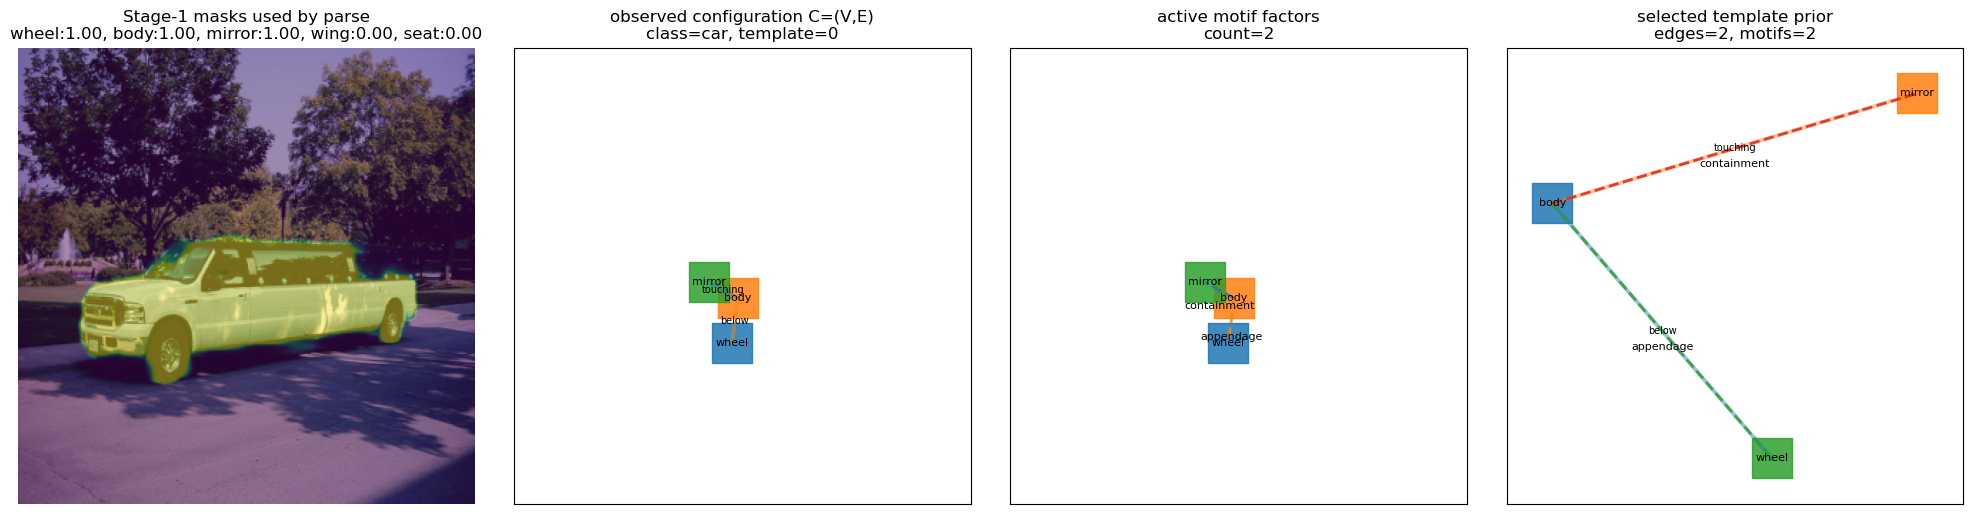

Direct parse summary


,gt_idx,gt,pred_idx,pred,explained_class_idx,explained_class,template,final_top5,base_pred,hkg_pred,hkg_logit_explained,node_logit_explained,edge_logit_explained,motif_logit_explained
0,6,car,6,car,6,car,0,"car:13.28, bicycle:2.42, biped:1.80, quadruped:1.21, boat:1.18",car,car,13.477707,5.287512,-0.027747,1.597122


Positive observed edges only


,edge_idx,part_i_idx,part_i,part_j_idx,part_j,role_i,role_j,relation_type,support,information_gain,strength,ll_template,ll_global,llr,edge_score_mode,edge_used_by_model,edge_draw_score,edge_contribution,top_observed_channel,top_observed_channel_strength,top_template_channel,top_template_channel_strength,obs_dx,template_dx,resid_z_dx,obs_dy,template_dy,resid_z_dy,obs_dist,template_dist,resid_z_dist,obs_area_i,template_area_i,resid_z_area_i,obs_area_j,template_area_j,resid_z_area_j,obs_log_area_ratio,template_log_area_ratio,resid_z_log_area_ratio,obs_bbox_w_i,template_bbox_w_i,resid_z_bbox_w_i,obs_bbox_h_i,template_bbox_h_i,resid_z_bbox_h_i,obs_bbox_w_j,template_bbox_w_j,resid_z_bbox_w_j,obs_bbox_h_j,template_bbox_h_j,resid_z_bbox_h_j,obs_iou,template_iou,resid_z_iou,obs_contact,template_contact,resid_z_contact,obs_contain_i_in_j,template_contain_i_in_j,resid_z_contain_i_in_j,obs_contain_j_in_i,template_contain_j_in_i,resid_z_contain_j_in_i


Positive motif factors only


,motif_idx,part_i,part_j,motif_type,support,strength,motif_value,learned_motif_weight,motif_contribution
1,44,body,mirror,containment,0.99916,0.955460,0.992248,2.944726,0.535043
0,43,body,wheel,appendage,0.99916,0.999971,0.300094,3.013671,0.173321


In [14]:
fig, direct_detail = plot_parse_configuration_and_motifs(
    model,
    selected_batch,
    index=int(row["batch_row"]),
    class_idx=class_idx,
    top_parts=10,
    mask_threshold=MASK_THRESHOLD,
    min_edge_contribution=1e-4,
    min_motif_contribution=1e-5,
)
save_figure(fig, "stage2_direct_configuration_and_motifs", subdir="stage2_parse")
plt.show()

print("Direct parse summary")
display(pd.DataFrame([direct_detail["summary"]]))
print("Positive observed edges only")
edge_view = direct_detail["edge_df"].copy()
if len(edge_view):
    edge_view = edge_view[edge_view["edge_contribution"] > 1e-4]
display(edge_view.head(20))
print("Positive motif factors only")
motif_view = direct_detail["motif_df"].copy()
if len(motif_view):
    motif_view = motif_view[motif_view["motif_contribution"] > 1e-5]
display(motif_view.head(20))

## 9. Template usage analysis

This checks whether the Or-node alternatives are being used. If one template dominates every class, the alternatives may be redundant; if many low-prior templates are selected, the template scorer may be unstable.

Template usage by predicted final class


,pred_final,best_template_pred,count
6,boat,0,9
14,reptile,0,9
12,quadruped,0,9
1,bicycle,0,8
15,snake,0,8
7,bottle,0,7
0,aeroplane,0,7
2,biped,0,6
10,fish,0,6
8,car,0,6


Template usage by GT class


,gt,best_template_gt,count
0,aeroplane,0,8
1,bicycle,0,8
6,boat,0,8
7,bottle,0,8
15,snake,0,8
14,reptile,0,8
2,biped,0,7
12,quadruped,0,7
10,fish,0,6
8,car,0,6


[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/017_stage2_template_usage_heatmap.png


PosixPath('/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/017_stage2_template_usage_heatmap.png')

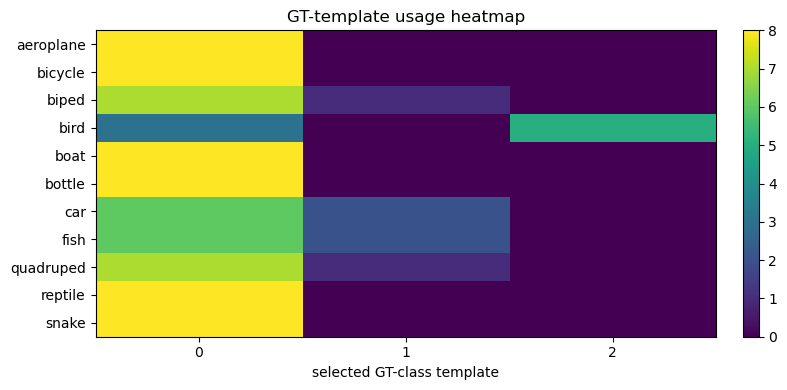

In [15]:
template_usage_pred = pred_df.groupby(["pred_final", "best_template_pred"]).size().reset_index(name="count")
template_usage_gt = pred_df.groupby(["gt", "best_template_gt"]).size().reset_index(name="count")
print("Template usage by predicted final class")
display(template_usage_pred.sort_values("count", ascending=False).head(30))
print("Template usage by GT class")
display(template_usage_gt.sort_values("count", ascending=False).head(30))

# Heatmap for the most frequent GT classes in this diagnostic subset.
top_gt = pred_df["gt"].value_counts().head(20).index.tolist()
pivot = template_usage_gt[template_usage_gt["gt"].isin(top_gt)].pivot_table(index="gt", columns="best_template_gt", values="count", fill_value=0)
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(pivot))))
im = ax.imshow(pivot.to_numpy(), aspect="auto")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_xlabel("selected GT-class template")
ax.set_title("GT-template usage heatmap")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
save_figure(fig, "stage2_template_usage_heatmap")

## 10. Relation-template residual analysis

For each image, this compares observed role-mask relation features against the selected template relation means. High `mean_abs_z_residual` means the observed relation is far from the class-template relation prior.

Run on a subset first; this is more expensive than branch-level statistics because it decodes selected-template edges for every image.

Edge residuals for GT-class selected templates


,sample_index,batch_index,gt,pred,class_source,class,template,edge_idx,part_i,part_j,support,information_gain,mean_abs_z_residual,max_abs_z_residual,ll_template,ll_global,llr
0,0,0,bicycle,bicycle,gt,bicycle,0,17,body,wheel,0.997561,6.235602e-01,0.666305,1.338761,1.679305,0.890313,0.788993
1,0,0,bicycle,bicycle,gt,bicycle,0,18,body,head,0.997561,3.072712e-01,0.535253,1.085247,1.807711,1.271615,0.536096
2,0,0,bicycle,bicycle,gt,bicycle,0,19,head,wheel,1.000000,0.000000e+00,0.368908,1.307028,2.127596,2.127596,0.000000
3,0,0,bicycle,bicycle,gt,bicycle,0,20,body,seat,0.636585,1.502144e-02,0.610123,1.169078,1.825687,1.724403,0.101284
4,0,0,bicycle,bicycle,gt,bicycle,0,21,head,seat,0.636585,6.201255e-05,0.580625,1.374035,1.232079,1.231206,0.000873
5,1,0,car,car,gt,car,0,64,body,wheel,0.999160,1.045545e-01,0.508086,1.397696,2.171762,1.720711,0.451051
6,1,0,car,car,gt,car,0,65,body,mirror,0.999160,4.918991e-04,0.372328,1.062272,2.118201,2.105679,0.012523
7,2,0,aeroplane,boat,gt,aeroplane,0,0,body,tail,0.995283,2.984909e-01,1.601273,5.749980,-0.237935,-0.046785,-0.191151
8,2,0,aeroplane,boat,gt,aeroplane,0,1,body,head,0.995283,2.624489e-01,1.976751,4.261450,-0.824598,-1.480345,0.655747
9,2,0,aeroplane,boat,gt,aeroplane,0,2,head,tail,1.000000,2.190760e-01,1.496844,6.378757,-1.065526,0.100270,-1.165796


Worst relation residuals


,sample_index,batch_index,gt,pred,class_source,class,template,edge_idx,part_i,part_j,support,information_gain,mean_abs_z_residual,max_abs_z_residual,ll_template,ll_global,llr
356,84,21,bicycle,bicycle,gt,bicycle,0,17,body,wheel,0.997561,6.235602e-01,3.395292,10.833878,-8.925789,-5.768231,-3.157558e+00
202,45,11,bottle,quadruped,gt,bottle,0,63,body,mouth,1.000000,1.621112e-14,3.059367,7.933066,-7.028915,-7.028916,4.768372e-07
194,43,10,snake,snake,gt,snake,0,96,body,head,1.000000,2.808344e-01,2.845077,9.357019,-5.501169,-3.878721,-1.622448e+00
245,56,14,car,car,gt,car,0,64,body,wheel,0.999160,1.045545e-01,2.502876,5.567446,-2.590298,-0.914378,-1.675920e+00
358,84,21,bicycle,bicycle,gt,bicycle,0,19,head,wheel,1.000000,0.000000e+00,2.457137,11.190904,-6.036040,-6.036040,0.000000e+00
249,57,14,biped,biped,gt,biped,1,37,body,hand,0.546703,2.832095e-02,2.449519,9.523577,-3.657278,-4.640194,9.829156e-01
81,19,4,biped,quadruped,gt,biped,0,28,body,foot,0.980769,2.295615e-01,2.442131,9.336819,-3.532023,-2.210041,-1.321982e+00
178,38,9,boat,boat,gt,boat,0,62,body,sail,1.000000,8.309958e-17,2.434888,11.653993,-5.492668,-5.492668,0.000000e+00
223,50,12,biped,biped,gt,biped,0,32,body,hand,0.963077,6.910715e-03,2.366740,10.526359,-4.330211,-4.005130,-3.250809e-01
85,19,4,biped,quadruped,gt,biped,0,32,body,hand,0.963077,6.910715e-03,2.330579,9.824306,-3.847474,-3.556665,-2.908092e-01


,class,part_i,part_j,n,mean_abs_z,mean_llr,support
13,biped,body,hand,8,1.601848,2.114680e-02,0.911030
9,bicycle,body,wheel,8,1.429095,-4.169610e-01,0.997561
17,biped,hand,head,8,1.199339,-1.185173e-01,0.930989
28,bottle,body,mouth,8,1.194713,8.568168e-08,1.000000
46,reptile,foot,tail,8,1.173037,-1.381932e-01,0.476037
7,bicycle,body,head,8,1.169660,1.185960e-01,0.997561
10,bicycle,head,seat,8,1.165119,-4.065394e-03,0.636585
16,biped,foot,tail,7,1.123754,1.933532e-01,0.416154
8,bicycle,body,seat,8,1.115417,-1.475833e-01,0.636585
11,bicycle,head,wheel,8,1.115268,0.000000e+00,1.000000


[saved figure] /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/018_stage2_relation_residual_histogram.png


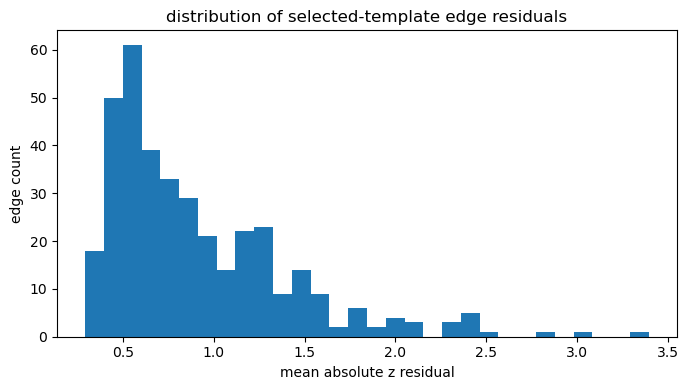

In [16]:
edge_residuals_gt = collect_edge_residuals(
    model,
    diag_loader,
    device=device,
    class_source="gt",
    max_batches=MAX_BATCHES,
    mask_threshold=MASK_THRESHOLD,
)
print("Edge residuals for GT-class selected templates")
display(edge_residuals_gt.head(20))

if len(edge_residuals_gt):
    print("Worst relation residuals")
    display(edge_residuals_gt.sort_values("mean_abs_z_residual", ascending=False).head(20))
    agg = edge_residuals_gt.groupby(["class", "part_i", "part_j"]).agg(
        n=("edge_idx", "size"),
        mean_abs_z=("mean_abs_z_residual", "mean"),
        mean_llr=("llr", "mean"),
        support=("support", "mean"),
    ).reset_index().sort_values("mean_abs_z", ascending=False)
    display(agg.head(20))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(edge_residuals_gt["mean_abs_z_residual"].to_numpy(), bins=30)
    ax.set_title("distribution of selected-template edge residuals")
    ax.set_xlabel("mean absolute z residual")
    ax.set_ylabel("edge count")
    fig.tight_layout()
    save_figure(fig, "stage2_relation_residual_histogram")

## 11. Save diagnostic tables

The saved CSV files can be used for paper plots, error analysis, or comparison across checkpoints.

In [17]:
tables_to_save = {
    "hkg_templates": hkg_tables["templates"],
    "hkg_roles": hkg_tables["roles"],
    "hkg_edges": hkg_tables["edges"],
    "hkg_motifs": hkg_tables["motifs"],
    "stage1_summary": stage1_summary,
    "stage1_per_part": stage1_per_part,
    "stage2_per_image": pred_df,
    "stage2_branch_summary": branch_summary,
    "stage2_class_summary": class_summary,
    "template_usage_pred": template_usage_pred,
    "template_usage_gt": template_usage_gt,
    "template_structure_quality": template_quality,
    "edge_residuals_gt": edge_residuals_gt,
}
save_diagnostic_tables(OUTPUT_DIR, tables_to_save)
print("Saved diagnostics to", OUTPUT_DIR)

if SAVE_FIGURES:
    figure_manifest, figure_zip = finalize_figure_exports()
    display(figure_manifest)


Saved diagnostics to /home/dfli/partcat_hkg_v3/runs/diagnostics/aog_hkg
Saved 18 figures to /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images
Zipped figures to /home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images.zip


,idx,name,path,filename,subdir
0,1,hkg_structure_histograms,/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/001_hkg_structure_histograms.png,001_hkg_structure_histograms.png,
1,2,hkg_class_templates_grid_car,/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/002_hkg_class_templates_grid_car.png,002_hkg_class_templates_grid_car.png,hkg_templates
2,3,hkg_template_configuration_car,/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/003_hkg_template_configuration_car.png,003_hkg_template_configuration_car.png,hkg_templates
3,4,hkg_class_templates_grid_aeroplane,/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/004_hkg_class_templates_grid_aeroplane.png,004_hkg_class_templates_grid_aeroplane.png,hkg_templates
4,5,hkg_template_configuration_aeroplane,/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/005_hkg_template_configuration_aeroplane.png,005_hkg_template_configuration_aeroplane.png,hkg_templates
5,6,hkg_class_templates_grid_bird,/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/006_hkg_class_templates_grid_bird.png,006_hkg_class_templates_grid_bird.png,hkg_templates
6,7,hkg_template_configuration_bird,/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/hkg_templates/007_hkg_template_configuration_bird.png,007_hkg_template_configuration_bird.png,hkg_templates
7,8,stage1_sample_00,/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/stage1_samples/008_stage1_sample_00.png,008_stage1_sample_00.png,stage1_samples
8,9,stage1_sample_01,/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/stage1_samples/009_stage1_sample_01.png,009_stage1_sample_01.png,stage1_samples
9,10,stage1_sample_02,/home/dfli/partcat_hkg_v3/notebooks/aog_hkg_diagnostic_images/stage1_samples/010_stage1_sample_02.png,010_stage1_sample_02.png,stage1_samples


## 12. Suggested interpretation checklist

Use this checklist after running the notebook:

1. If Stage-1 `mean_hallucination_rate` is high, inspect top hallucinated parts before blaming HKG relations.
2. If `base` is strong but `final` drops, check damage examples and the HKG calibration scale.
3. If `hkg` is poor but `node` is reasonable, relation templates or template selection may be noisy.
4. If `edge` is always near-zero, inspect edge support and `llr` distributions.
5. If one template dominates every class, increase template diversity or inspect clustering features.
6. If relation residuals are high for a specific edge type, either masks are poor or the template relation is too rigid.
7. If rescue examples look semantically plausible, the HKG is adding useful compositional bias; if damage examples show hallucinated parts, tune presence thresholds or absence/conflict penalties.

Additional guardrails added in this version:

- First check the diagnostic loader class-balance table. If it has only one class, confusion matrices and calibration curves are not meaningful.
- Use the individual part-mask panel, not only the union overlay, to detect part-channel collapse or hallucination.
- If the run log says `motifs` is close to `edges`, the loaded HKG checkpoint is stale or too permissive; rebuild the HKG and rerun Stage 2.
- If `base_acc` drops while `final_acc` stays high, the loaded Stage-2 checkpoint was likely trained without a base auxiliary loss or with an overly strong HKG fusion weight.
